<table style="width:100%">
<tr>                                                                                   
     <th>
        <div style="padding:15px;color:#030aa7;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif">Analyse exploratoire des données météorologiques</div>
        <div style="padding:10px;text-align:center;color:#030aa7;font-size:120%;font-family:Georgia,serif">Températures · Précipitations · Vent · Humidité · Pression</div>
         <div style='text-align:center;color:#030aa7;font-size:120%;font-family:Georgia,serif'><b>3 603 593 observations</b> &nbsp; | &nbsp; <b>1996–2026</b> &nbsp; | &nbsp; <b>Source : meteo.gzip / Parquet</b></div>
     </th>
 </tr>
<tr>                                                                                   
     <th><img src="https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/analyse_meteoFrance.png" width="1024"></th>
 </tr>    
</table>


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Introduction</div></b>

Notebook adapté après lecture réelle de **meteo.gzip** : **3 603 593 observations**, du **1er janvier 1996 au 15 janvier 2026**. Malgré son extension, le fichier est un **Parquet compressé**, reconnaissable à sa signature `PAR1`. Son index multiple contient `Nom`, `Latitude`, `Longitude`, `Altitude`, `Zone` ; ses 16 colonnes incluent les mesures et des repères calendaires.

Exécuter les cellules dans l'ordre. Placer le fichier original à côté du notebook ou renseigner `SOURCE`. La copie brute `donnees/00_brutes.parquet` constitue aussi une entrée autonome pour les exécutions suivantes. Prévoir plusieurs Go de mémoire libre pour la lecture et les copies de cette table.

**Traçabilité :** toutes les tables exportées sont en Parquet, les illustrations en PNG. Les sorties affichées dans le notebook sont des aperçus. Aucune sauvegarde CSV ou JSON de données n'est créée.

**Interprétation :** les unités ne figurent pas explicitement dans le schéma. °C, %, hPa, mm, m/s et degrés sont des hypothèses plausibles à confirmer auprès du producteur. Aucune conversion d'unité n'est appliquée. La durée d'accumulation de `Precipitation` n'est pas documentée : les sommes sont des **sommes de relevés**, pas des cumuls climatologiques certifiés. Les dates sont sans fuseau ; aucune localisation arbitraire n'est ajoutée.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Import des bibliothèques</div></b>

Bibliothèques : pandas, pyarrow, numpy et matplotlib. Si nécessaire, exécuter `%pip install -U pandas "pyarrow>=25" matplotlib` dans une cellule puis redémarrer le noyau. Une ancienne version de pyarrow présente une erreur de lecture des métadonnées sur ce fichier ; la lecture a été vérifiée avec pyarrow 25.0.1.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from datetime import datetime as dt
import matplotlib.font_manager as fm
import matplotlib.patheffects as path_effects

font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

plt.rcParams.update({"figure.dpi": 110, 
                     "figure.figsize": [36.0, 12.0],
                     "axes.spines.top": False,
                     "axes.spines.right": False, 
                     "font.size": 18,
                    'figure.titlesize': 'x-large',
                    'figure.labelsize': 'x-large'})

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=3)

# Charte graphique du notebook de référence : bleu profond et fond gris clair.
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
plt.rcParams.update({
    'figure.figsize': (18, 6), 'figure.dpi': 110,
    'axes.prop_cycle': plt.cycler(color=palette),
    'axes.titlecolor': '#030aa7', 'axes.titleweight': 'bold',
    'axes.facecolor': '#f5f6f5', 'axes.grid': True, 'axes.axisbelow': True,
    'grid.alpha': .3, 'grid.color': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 12,
})
print('Versions :', pd.__version__, pa.__version__)

Versions : 2.3.3 25.0.1


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Configuration et outils du document</div></b>

Adapter `SOURCE` au besoin. Par défaut, les courbes par station portent sur les huit stations ayant le plus de températures valides, pendant la dernière année civile complète disponible. Les autres graphiques utilisent cette même période ; le graphique mensuel final utilise toute l'histoire. La liste peut être remplacée par des noms précis. Les stations moins documentées restent présentes dans les données et dans les agrégations exportées.

In [2]:
SOURCE = Path("/opt/spark/data/meteo.gzip")
DATA = Path('donnees')
FIGURES = Path('figures')
DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
ANNEE_ANALYSE = None  # None : année précédant la dernière date du fichier.
STATIONS_CHOISIES = None  # Exemple : ['Abbeville'] ; None : sélection automatique.
N_STATIONS = 8
# Unités présumées : modifier les libellés après vérification du dictionnaire source.
UNITES = {'Temperature': '°C', 'Precipitation': 'mm', 'VitesseVent': 'm/s',
          'Humidite': '%', 'Pression': 'hPa', 'Visibilite': 'km'}

def sauver(table, nom):
    """Un seul point de sortie pour les tables : Parquet, sans index implicite."""
    table.to_parquet(DATA / (nom + '.parquet'), engine='pyarrow',
                     compression='snappy', index=False)
    return table

def terminer(fig, nom):
    """Exporter l'illustration et l'afficher dans le notebook."""
    fig.tight_layout()
    fig.savefig(FIGURES / (nom + '.png'), dpi=140, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def disponible(table, colonnes):
    """Ne pas tracer un graphique trompeur si les mesures font défaut."""
    ok = all(c in table and table[c].notna().any() for c in colonnes)
    if not ok:
        print('Graphique indisponible :', ', '.join(colonnes))
    return ok

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Lecture des données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Description des variables</div></b>

| Famille | Variables disponibles | Utilisation |
|---|---|---|
| Temps | `DateHeure` et repères calendaires | Évolutions quotidiennes et mensuelles |
| Stations | `Nom`, `Latitude`, `Longitude`, `Altitude`, `Zone` | Comparaisons et carte ; niveaux de l’index original |
| Température | `Temperature` | Moyenne, minimum, maximum, distribution, gel |
| Précipitations | `Precipitation` | Sommes de relevés, classement, distribution |
| Vent | `DirectionVent`, `VitesseVent` | Rose des vents et classes de vitesse |
| Atmosphère | `Humidite`, `Pression`, `Visibilite` | Conditions atmosphériques et corrélations |
| Ensoleillement | Aucune colonne disponible | Absence documentée ; aucune estimation inventée |

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Inspection du fichier et copie brute</div></b>

L'extension ne définit pas le format. Vérifier la signature Parquet, lire le schéma puis remettre les niveaux de l'index en colonnes. La copie brute conserve les valeurs, les dates et les coordonnées sans nettoyage. Examiner les types, valeurs manquantes, plages et doublons avant de tracer.

In [3]:
if not SOURCE.exists():
    SOURCE = DATA / '00_brutes.parquet'
if not SOURCE.exists():
    raise FileNotFoundError('Placer meteo.gzip à côté du notebook ou adapter SOURCE.')
with SOURCE.open('rb') as fichier:
    if fichier.read(4) != b'PAR1':
        raise ValueError('Cette entrée doit être le fichier Parquet météo inspecté.')
print(pq.ParquetFile(SOURCE).schema)
try:
    brut = pd.read_parquet(SOURCE, engine='pyarrow')
except OSError as exc:
    raise RuntimeError('Mettre à jour pyarrow (version 25 ou ultérieure), puis redémarrer le noyau.') from exc
# Les informations des stations ne sont pas des colonnes dans l'original.
if any(n is not None for n in brut.index.names):
    brut = brut.reset_index()
sauver(brut, '00_brutes')
inspection = pd.DataFrame({'colonne': brut.columns,
                          'type': brut.dtypes.astype(str).values,
                          'manquants': brut.isna().sum().values,
                          'pourcentage_manquant': brut.isna().mean().values * 100})
sauver(inspection, '01_inspection')
print('Dimensions :', brut.shape, '| Stations :', brut['Nom'].nunique())
print('Dates :', brut['DateHeure'].min(), 'à', brut['DateHeure'].max())
display(brut.head(), inspection)
display(brut.select_dtypes('number').describe().T)

required group field_id=-1 schema {
  optional int64 field_id=-1 DateHeure (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional double field_id=-1 DirectionVent;
  optional double field_id=-1 VitesseVent;
  optional double field_id=-1 Temperature;
  optional double field_id=-1 Humidite;
  optional double field_id=-1 Visibilite;
  optional double field_id=-1 Pression;
  optional double field_id=-1 Precipitation;
  optional int32 field_id=-1 JourA;
  optional int32 field_id=-1 Semaine (Int(bitWidth=32, isSigned=false));
  optional int32 field_id=-1 Mois;
  optional int32 field_id=-1 Annee;
  optional int32 field_id=-1 MoisJour;
  optional int32 field_id=-1 AnneeMois;
  optional int64 field_id=-1 AnneeSemaine;
  optional int32 field_id=-1 AnneeJour;
  optional binary field_id=-1 Nom (String);
  optional double field_id=-1 Latitude;
  optional double field_id=-1 Longitude;
  optional int32 field_id=-1 Altitude (I

,Nom,Latitude,Longitude,Altitude,Zone,DateHeure,DirectionVent,VitesseVent,Temperature,Humidite,...,Pression,Precipitation,JourA,Semaine,Mois,Annee,MoisJour,AnneeMois,AnneeSemaine,AnneeJour
0,Abbeville,50.136,1.834,69,NO,1996-01-01 00:00:00,170.0,2.0,2.89,99.0,...,990.9,0.0,1,1,1,1996,101,199601,199601,1996001
1,Abbeville,50.136,1.834,69,NO,1996-01-01 03:00:00,130.0,3.0,2.70,99.0,...,990.7,0.2,1,1,1,1996,101,199601,199601,1996001
2,Abbeville,50.136,1.834,69,NO,1996-01-01 06:00:00,120.0,3.0,2.89,99.0,...,990.9,0.0,1,1,1,1996,101,199601,199601,1996001
3,Abbeville,50.136,1.834,69,NO,1996-01-01 09:00:00,130.0,4.1,3.60,99.0,...,991.1,0.0,1,1,1,1996,101,199601,199601,1996001
4,Abbeville,50.136,1.834,69,NO,1996-01-01 12:00:00,100.0,5.1,4.39,99.0,...,990.4,0.0,1,1,1,1996,101,199601,199601,1996001


,colonne,type,manquants,pourcentage_manquant
0,Nom,object,0,0.000000
1,Latitude,float64,0,0.000000
2,Longitude,float64,0,0.000000
3,Altitude,int16,0,0.000000
4,Zone,object,0,0.000000
5,DateHeure,datetime64[ns],0,0.000000
6,DirectionVent,float64,8400,0.233101
7,VitesseVent,float64,7961,0.220918
8,Temperature,float64,21128,0.586304
9,Humidite,float64,27972,0.776225


,count,mean,std,min,25%,50%,75%,max
Latitude,3603593.0,46.211754,2.413085,41.918,43.909833,46.046833,48.4455,50.57
Longitude,3603593.0,2.407784,3.391362,-4.412,0.0,2.359833,5.077833,9.485167
Altitude,3603593.0,175.572294,209.702923,2.0,42.0,108.0,235.0,871.0
DirectionVent,3595193.0,187.102801,107.303796,0.0,90.0,200.0,280.0,360.0
VitesseVent,3595632.0,3.812988,2.660422,0.0,2.0,3.1,5.1,47.2
Temperature,3582465.0,12.712427,7.334499,-21.3,7.7,12.5,17.6,96.0
Humidite,3575621.0,75.63236,17.704062,1.0,64.0,80.0,90.0,100.0
Visibilite,3136248.0,22.730658,15.39308,0.0,12.0,20.0,30.0,80.01
Pression,3572969.0,995.658704,25.327961,434.0,986.8,1002.8,1012.3,1050.9
Precipitation,3567273.0,0.258369,1.323819,-0.3,0.0,0.0,0.0,443.0


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Nettoyage, typage et contrôle qualité</div></b>

Les dates invalides deviennent manquantes. Les mesures sont converties en nombres ; les infinis et valeurs physiquement suspectes sont remplacés par des valeurs manquantes, jamais par zéro. Bornes de contrôle configurables : température −90 à 60, humidité 0 à 100, pression 300 à 1100 (pour conserver les stations d'altitude), latitude ±90 et longitude ±180. Les précipitations négatives peuvent être des codes de trace : faute de dictionnaire, elles sont exclues des calculs et comptées dans le bilan. Les doublons stricts sont retirés ; les conflits station/date sont signalés, conservés et moyennés lors des agrégations. Les précipitations à ces dates sont moyennées avant toute somme pour éviter un double comptage. Aucune interpolation n'est imposée.

In [4]:
df = brut.copy()
df['DateHeure'] = pd.to_datetime(df['DateHeure'], errors='coerce')
df['Nom'] = df['Nom'].astype('string').str.strip().replace('', pd.NA)
mesures = ['Temperature', 'Precipitation', 'Humidite', 'Pression',
           'VitesseVent', 'DirectionVent', 'Visibilite', 'Latitude', 'Longitude', 'Altitude']
bilan = []
bornes = {'Temperature': (-90, 60), 'Humidite': (0, 100),
          'Pression': (300, 1100), 'Precipitation': (0, np.inf),
          'VitesseVent': (0, np.inf), 'DirectionVent': (0, 360),
          'Visibilite': (0, np.inf), 'Latitude': (-90, 90), 'Longitude': (-180, 180)}
for c in mesures:
    if c not in df:
        continue
    avant = df[c].notna()
    df[c] = pd.to_numeric(df[c], errors='coerce').replace([np.inf, -np.inf], np.nan)
    if c in bornes:
        bas, haut = bornes[c]
        df[c] = df[c].where(df[c].between(bas, haut))
    bilan.append({'variable': c, 'valeurs_exclues': int((avant & df[c].isna()).sum())})
# 360° correspond au nord ; les vents calmes seront isolés dans la rose.
if 'DirectionVent' in df:
    df['DirectionVent'] = df['DirectionVent'] % 360
nb_avant = len(df)
df = df.drop_duplicates().copy()
print('Doublons stricts retirés :', nb_avant - len(df))
print('Lignes en conflit station/date :', df.duplicated(['Nom', 'DateHeure'], keep=False).sum())
df['Jour'] = df['DateHeure'].dt.floor('D')
df['MoisDebut'] = df['DateHeure'].dt.to_period('M').dt.to_timestamp()
df['AnneeCalculee'] = df['DateHeure'].dt.year.astype('Int64')
sauver(pd.DataFrame(bilan), '02_bilan_nettoyage')
sauver(df, '03_nettoyees')
display(pd.DataFrame(bilan))
# La copie brute reste sur disque ; libérer sa place en mémoire.
del brut

Doublons stricts retirés : 181
Lignes en conflit station/date : 10


,variable,valeurs_exclues
0,Temperature,2
1,Precipitation,91902
2,Humidite,0
3,Pression,0
4,VitesseVent,0
5,DirectionVent,0
6,Visibilite,0
7,Latitude,0
8,Longitude,0
9,Altitude,0


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Préparation des tables et de la période</div></b>

La table d'observations uniques repose sur (station, date). La direction du vent est moyennée circulairement afin d'éviter qu'une moyenne de 350° et 10° donne 180°. Les statistiques quotidiennes et mensuelles sont sauvegardées avec leurs effectifs. Une somme sans observation reste manquante. Les minima et maxima sont ceux des mesures disponibles, pas nécessairement les extrema météorologiques quotidiens officiels. Les stations sans date/nom sont conservées dans le jeu nettoyé mais exclues des agrégations temporelles.

In [5]:
valides = df.dropna(subset=['Nom', 'DateHeure'])
colonnes = [c for c in mesures if c in valides and c != 'DirectionVent']
obs = valides.groupby(['Nom', 'DateHeure'], observed=True)[colonnes].mean().reset_index()
if 'DirectionVent' in valides:
    angles = valides[['Nom', 'DateHeure']].copy()
    angles['sin'] = np.sin(np.deg2rad(valides['DirectionVent']))
    angles['cos'] = np.cos(np.deg2rad(valides['DirectionVent']))
    angles = angles.groupby(['Nom', 'DateHeure'], observed=True)[['sin', 'cos']].mean()
    angles['DirectionVent'] = (np.rad2deg(np.arctan2(angles['sin'], angles['cos'])) + 360) % 360
    angles.loc[np.hypot(angles['sin'], angles['cos']) < 1e-8, 'DirectionVent'] = np.nan
    obs = obs.merge(angles[['DirectionVent']].reset_index(), on=['Nom', 'DateHeure'], how='left')
obs['Jour'] = obs['DateHeure'].dt.floor('D')
obs['MoisDebut'] = obs['DateHeure'].dt.to_period('M').dt.to_timestamp()
sauver(obs, '04_observations_uniques')
if obs.empty:
    raise ValueError('Aucune observation datée avec station exploitable.')
annee = int(ANNEE_ANALYSE if ANNEE_ANALYSE is not None else obs['DateHeure'].dt.year.max() - 1)
periode = obs.loc[obs['DateHeure'].dt.year.eq(annee)].copy()
if periode.empty:
    print('Année vide : utilisation de toute la période disponible.')
    periode = obs.copy()
stations = (list(STATIONS_CHOISIES) if STATIONS_CHOISIES is not None else
            periode.groupby('Nom')['Temperature'].count().nlargest(N_STATIONS).index.tolist())
spec = {'t_min': ('Temperature', 'min'), 't_moy': ('Temperature', 'mean'),
        't_max': ('Temperature', 'max'), 'n_temperature': ('Temperature', 'count'),
        'pluie': ('Precipitation', lambda s: s.sum(min_count=1)),
        'n_pluie': ('Precipitation', 'count'), 'humidite': ('Humidite', 'mean'),
        'pression': ('Pression', 'mean')}
journalier = periode.groupby(['Nom', 'Jour'], observed=True).agg(**spec).reset_index()
mensuel = obs.groupby(['Nom', 'MoisDebut'], observed=True).agg(
    temperature=('Temperature', 'mean'), n_temperature=('Temperature', 'count'),
    humidite=('Humidite', 'mean'), pression=('Pression', 'mean'),
    pluie=('Precipitation', lambda s: s.sum(min_count=1)),
    n_pluie=('Precipitation', 'count')).reset_index()
sauver(periode, '05_periode_graphiques')
sauver(journalier, '06_statistiques_journalieres')
sauver(mensuel, '07_statistiques_mensuelles')
print('Période des graphiques :', periode.DateHeure.min(), 'à', periode.DateHeure.max())
print('Stations illustrées :', ', '.join(stations))

Période des graphiques : 2025-01-01 00:00:00 à 2025-12-31 21:00:00
Stations illustrées : Bale, Strasbourg, Mont-De-Marsan, Rouen, Ajaccio, Caen, Alencon, Nice


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Statistiques descriptives et analyse des données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Températures et précipitations</div></b>

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 01 — Température au fil du temps, par station</div></b>

**Objectif :** comparer les variations saisonnières.

**Variables :** date, station, température.

**Préparation :** moyenne quotidienne par station ; seuls les noms sélectionnés sont dessinés.

**Lecture :** chaque courbe représente une station ; les jours manquants créent des interruptions et ne sont pas interpolés.

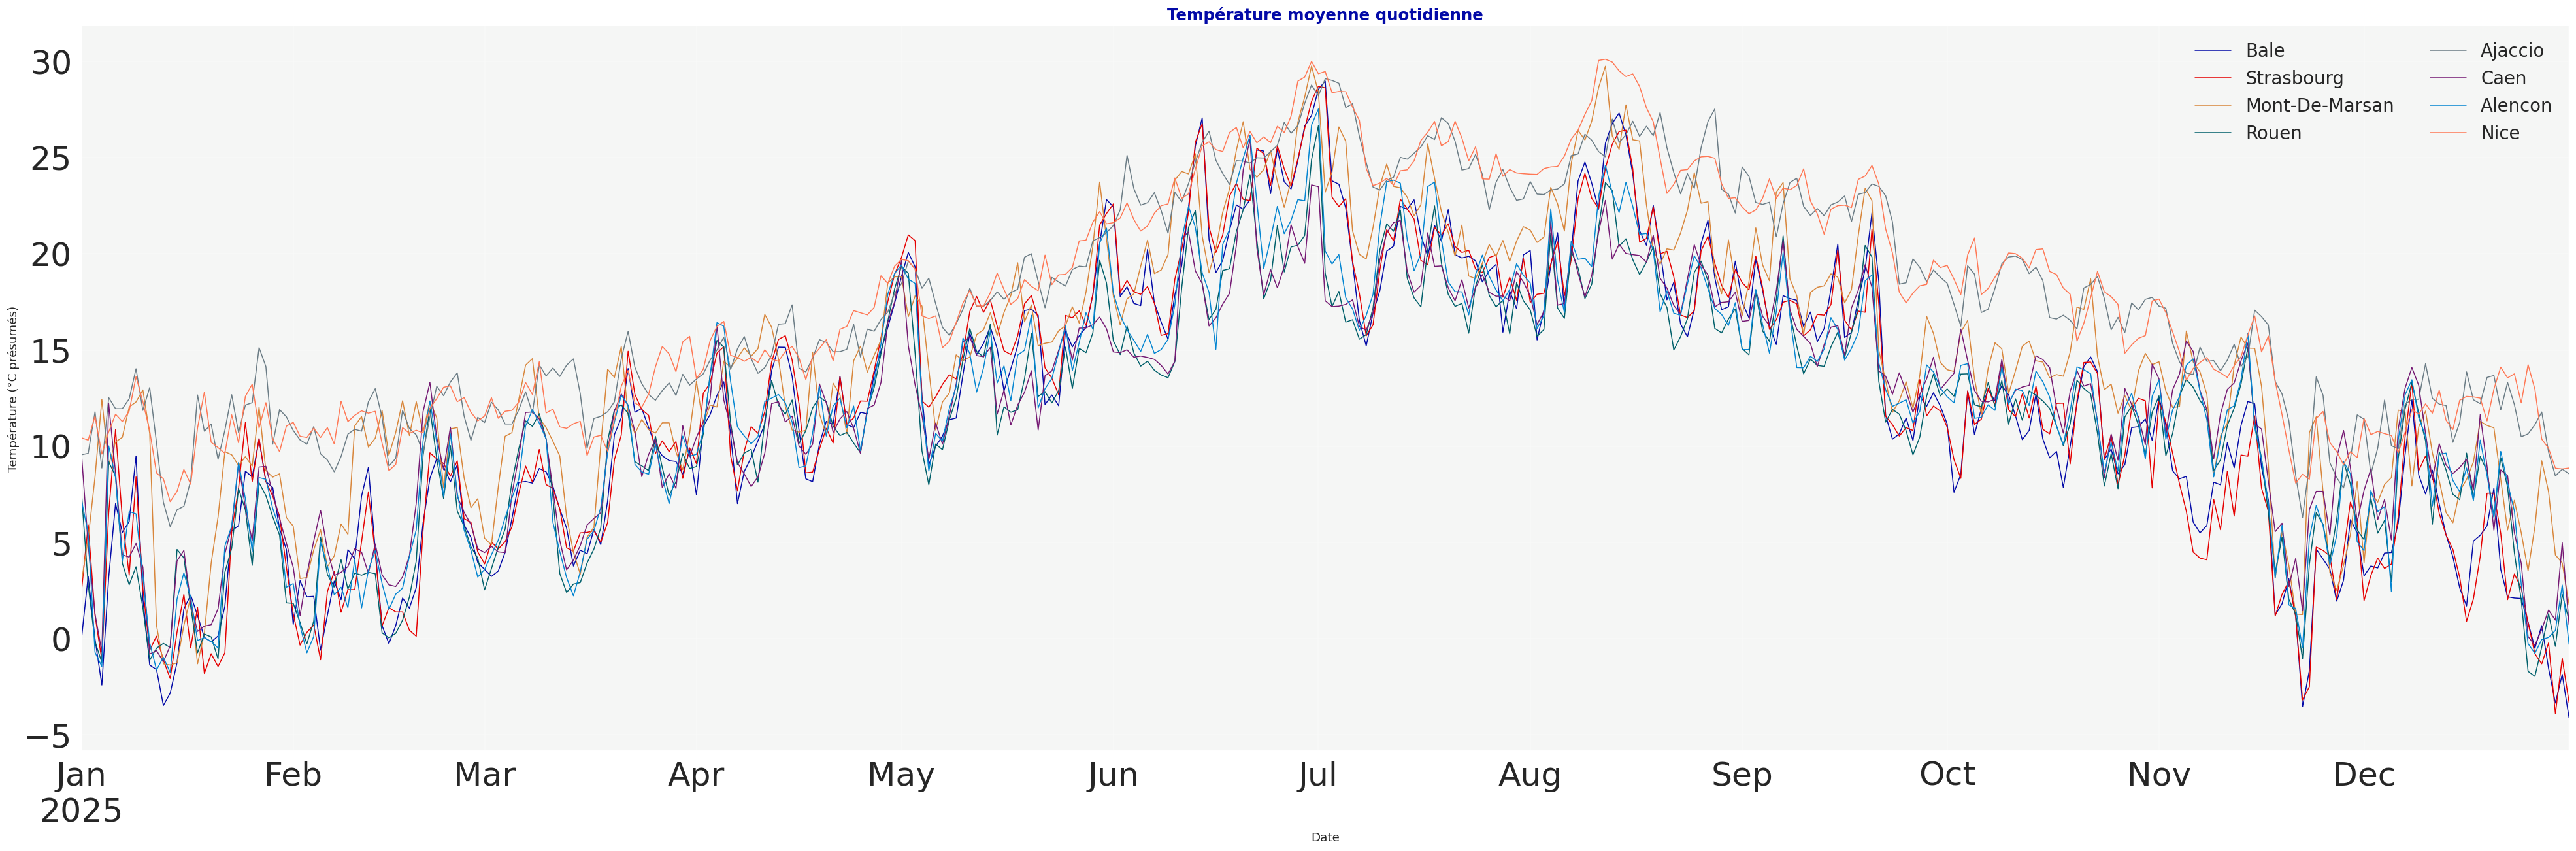

In [6]:
table = journalier.pivot(index='Jour', columns='Nom', values='t_moy')
table = table.reindex(pd.date_range(periode.Jour.min(), periode.Jour.max(), freq='D'))
table.index.name = 'Jour'
sauver(table.reset_index(), 'g01_temperature_par_station')
if disponible(periode, ['Temperature']):
    fig, ax = plt.subplots(figsize=(36, 12))
    # Reindexer conserve des trous visibles en l'absence de mesure.
    table.reindex(columns=stations).plot(ax=ax, linewidth=1)
    ax.set(title='Température moyenne quotidienne', xlabel='Date', ylabel='Température (°C présumés)')
    ax.legend(fontsize=18, ncol=2)
    terminer(fig, '01_temperature_stations')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 02 — Précipitations dans le temps</div></b>

**Objectif :** repérer les épisodes pluvieux.

**Variables :** date, précipitation, station.

**Préparation :** somme quotidienne des relevés par station puis moyenne entre stations disponibles, avec effectif journalier.

**Lecture :** les pics indiquent de fortes sommes observées ; la couverture varie. La somme suppose des intervalles non chevauchants, ce qui reste à vérifier. Un jour incomplet n'est pas extrapolé.

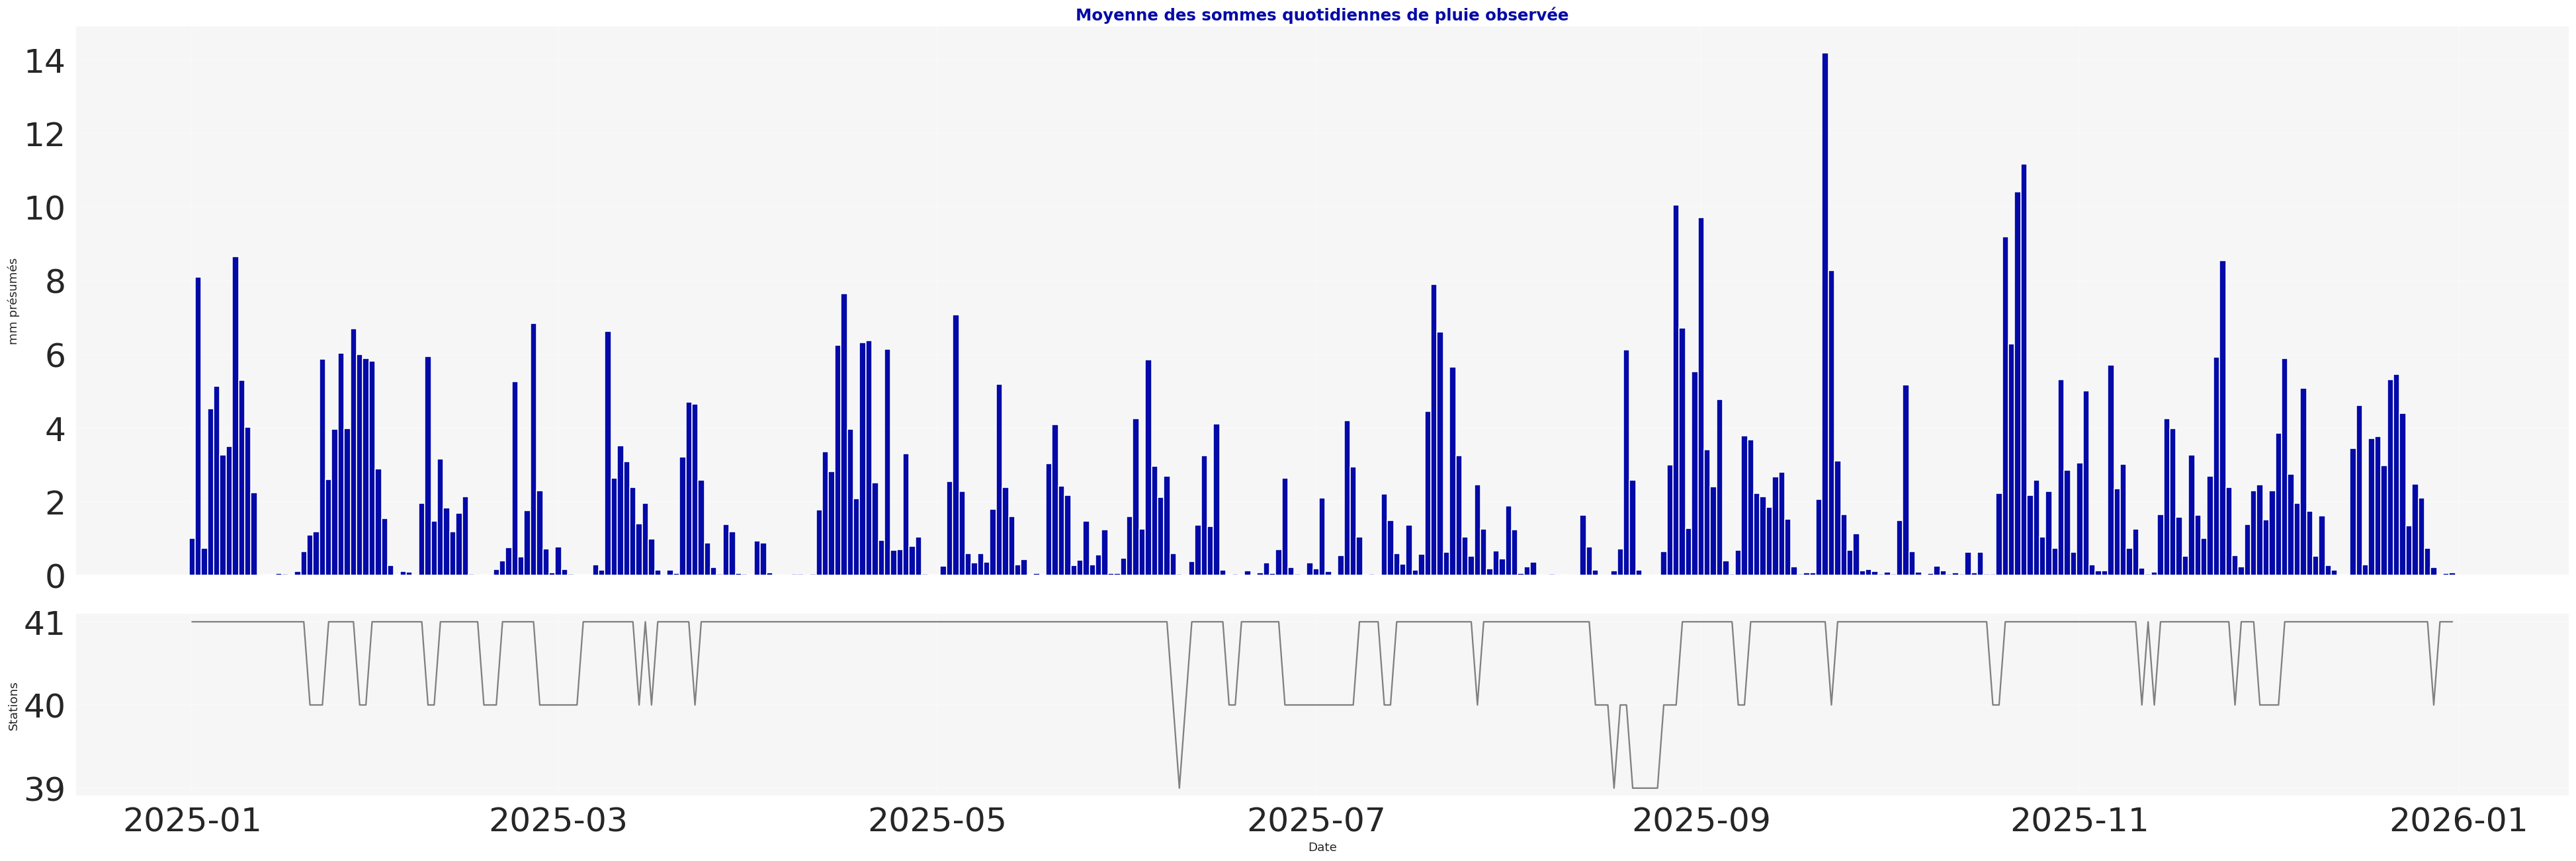

In [7]:
table = journalier.groupby('Jour').agg(pluie_moyenne=('pluie', 'mean'), stations=('pluie', 'count')).reset_index()
sauver(table, 'g02_precipitations')
if disponible(table, ['pluie_moyenne']):
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(36, 12), height_ratios=[3, 1])
    axes[0].bar(table.Jour, table.pluie_moyenne, width=1, color=palette[0])
    axes[0].set(title='Moyenne des sommes quotidiennes de pluie observée', ylabel='mm présumés')
    axes[1].plot(table.Jour, table.stations, color='gray')
    axes[1].set(ylabel='Stations', xlabel='Date')
    terminer(fig, '02_precipitations')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 03 — Températures minimale, moyenne et maximale</div></b>

**Objectif :** visualiser l'amplitude quotidienne d'une station.

**Variables :** température et date.

**Préparation :** minimum, moyenne et maximum des relevés du jour de la première station sélectionnée.

**Lecture :** le ruban représente l'étendue observée, pas un intervalle de confiance. Des relevés espacés peuvent manquer les extrema réels.

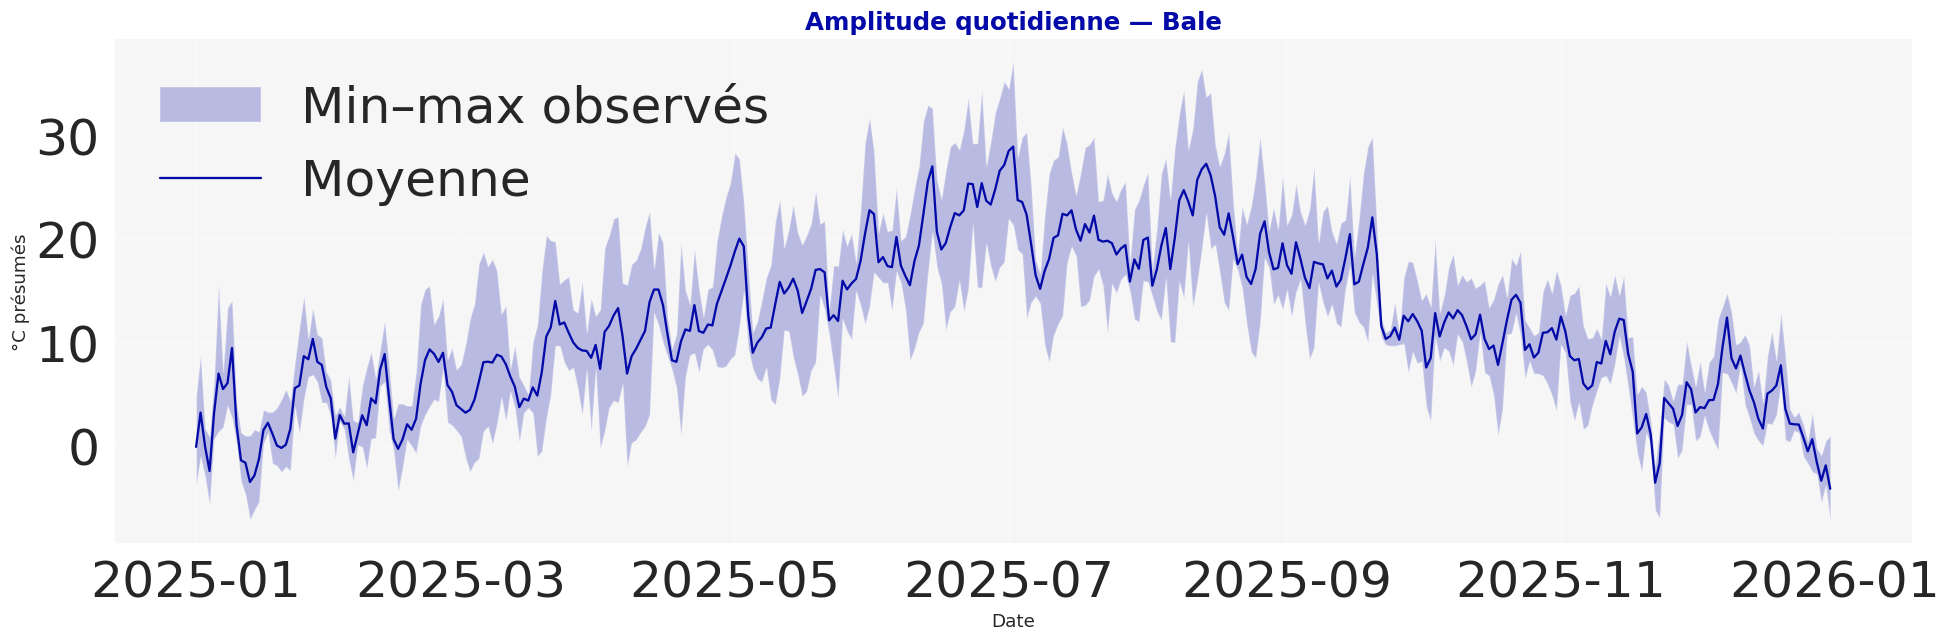

In [8]:
table = journalier.loc[journalier.Nom.eq(stations[0])].copy() if stations else journalier.iloc[:0].copy()
sauver(table, 'g03_temperature_min_moy_max')
if disponible(table, ['t_moy']):
    fig, ax = plt.subplots()
    # Étendue des observations, sans interprétation probabiliste.
    ax.fill_between(table.Jour, table.t_min, table.t_max, alpha=.25, label='Min–max observés')
    ax.plot(table.Jour, table.t_moy, label='Moyenne')
    ax.set(title='Amplitude quotidienne — ' + str(table.Nom.iloc[0]), ylabel='°C présumés', xlabel='Date')
    ax.legend()
    terminer(fig, '03_min_moy_max')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 04 — Carte géographique des températures</div></b>

**Objectif :** situer les contrastes spatiaux.

**Variables :** latitude, longitude, température.

**Préparation :** moyenne des relevés par station et coordonnées médianes ; toutes les stations de la période sont incluses.

**Lecture :** la couleur code la température. Cette carte de points sans fond externe n'interpole pas entre stations ; l'altitude et la couverture expliquent aussi les différences.

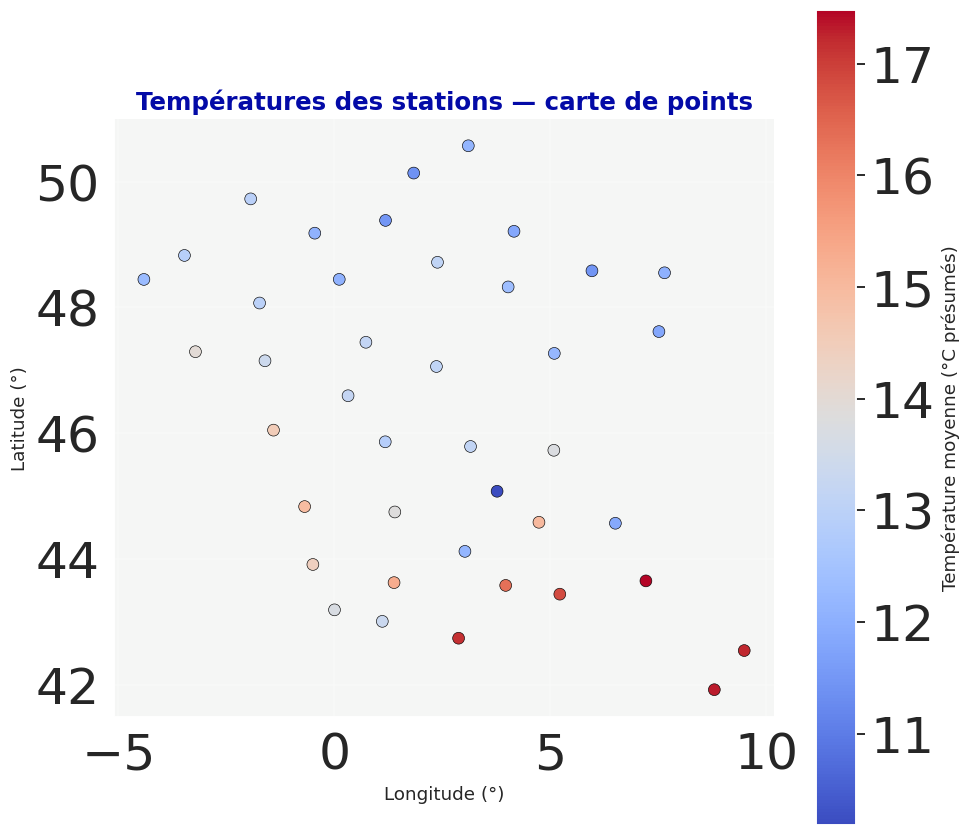

In [9]:
if disponible(periode, ['Latitude', 'Longitude', 'Temperature']):
    table = periode.groupby('Nom').agg(latitude=('Latitude', 'median'), longitude=('Longitude', 'median'),
        temperature=('Temperature', 'mean'), n=('Temperature', 'count')).reset_index()
    table = table.dropna(subset=['latitude', 'longitude', 'temperature'])
    sauver(table, 'g04_carte_temperature')
    fig, ax = plt.subplots(figsize=(9, 8))
    points = ax.scatter(table.longitude, table.latitude, c=table.temperature, cmap='coolwarm', s=60, edgecolors='black', linewidths=.4)
    fig.colorbar(points, ax=ax, label='Température moyenne (°C présumés)')
    ax.set(title='Températures des stations — carte de points', xlabel='Longitude (°)', ylabel='Latitude (°)')
    # Correction locale de l'aspect pour rendre les distances moins déformées.
    ax.set_aspect(1 / max(.1, np.cos(np.deg2rad(table.latitude.median()))))
    terminer(fig, '04_carte_temperature')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 05 — Distribution des températures</div></b>

**Objectif :** décrire les températures courantes et rares.

**Variable :** température des observations uniques.

**Préparation :** exclure uniquement les valeurs manquantes, puis compter 50 classes ; sauvegarder les bornes et effectifs.

**Lecture :** l'histogramme est pondéré par les observations, donc davantage par les stations les plus complètes.

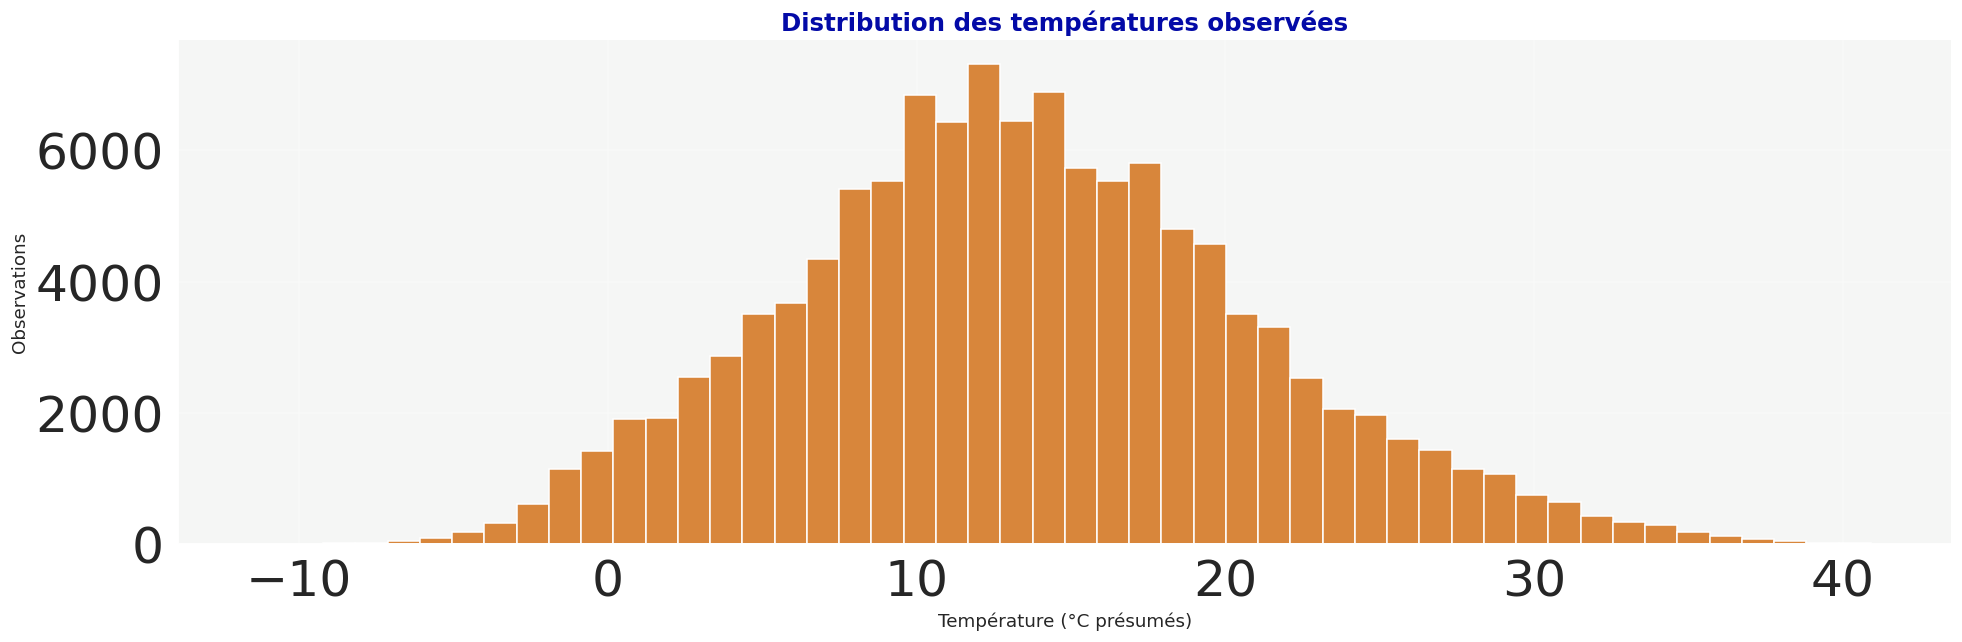

In [10]:
valeurs = periode.Temperature.dropna()
if not valeurs.empty:
    comptes, bornes_hist = np.histogram(valeurs, bins=50)
    table = pd.DataFrame({'borne_basse': bornes_hist[:-1], 'borne_haute': bornes_hist[1:], 'effectif': comptes})
    sauver(table, 'g05_distribution_temperature')
    fig, ax = plt.subplots()
    ax.bar(table.borne_basse, table.effectif, width=table.borne_haute-table.borne_basse, align='edge', color=palette[2], edgecolor='white')
    ax.set(title='Distribution des températures observées', xlabel='Température (°C présumés)', ylabel='Observations')
    terminer(fig, '05_distribution_temperature')
else:
    print('Aucune température disponible.')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Vent et conditions atmosphériques</div></b>

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 06 — Rose des vents</div></b>

**Objectif :** représenter direction et intensité du vent.

**Variables :** DirectionVent et VitesseVent.

**Préparation :** 16 secteurs centrés sur les points cardinaux, cinq classes de vitesse ; valeurs manquantes exclues. Les vents calmes (<0,5 en unité source) sont dénombrés séparément, même si leur direction manque.

**Lecture :** nord en haut, angles dans le sens horaire ; les pourcentages ont pour dénominateur les vents non calmes avec direction valide. La convention « direction d'où vient le vent » doit être confirmée.

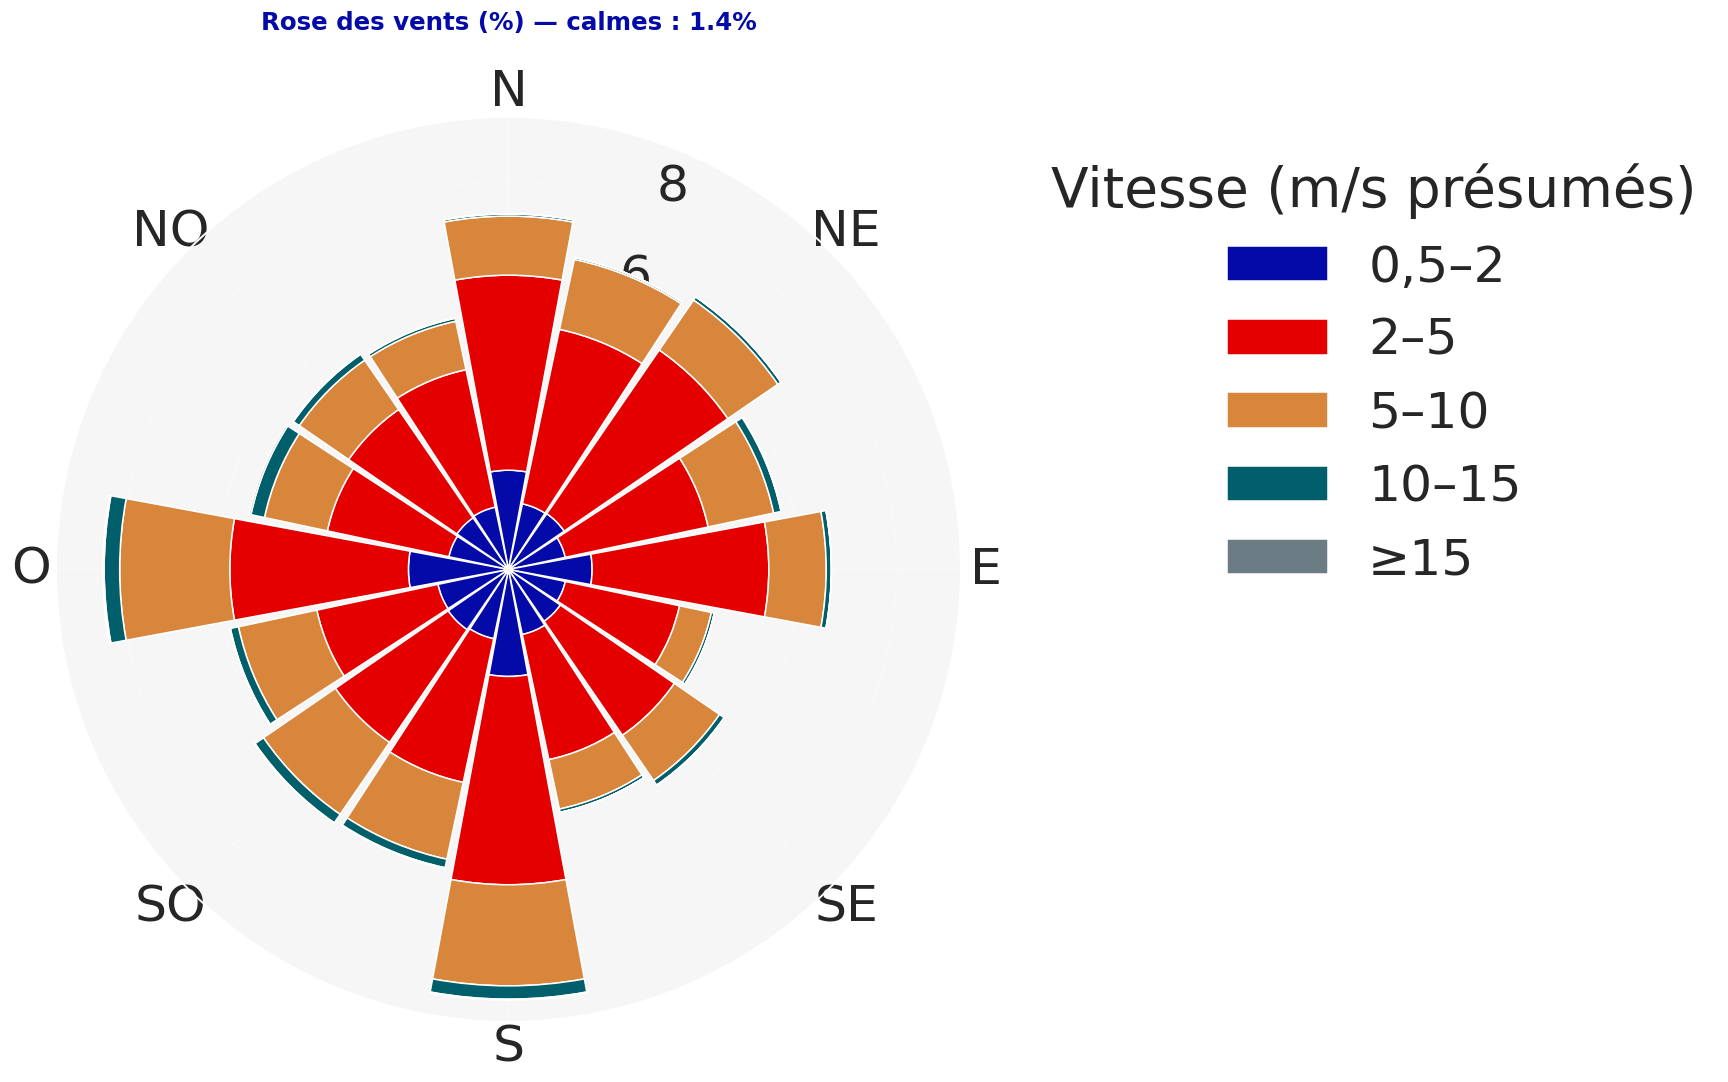

In [11]:
if disponible(periode, ['DirectionVent', 'VitesseVent']):
    vents = periode[['DirectionVent', 'VitesseVent']].copy()
    n_vitesse = int(vents.VitesseVent.notna().sum())
    n_calme = int(vents.VitesseVent.lt(.5).sum())
    vents = vents.dropna().loc[lambda d: d.VitesseVent.ge(.5)].copy()
    # Le décalage de 11,25° centre le premier secteur sur le nord.
    vents['secteur'] = (((vents.DirectionVent + 11.25) % 360) // 22.5).astype(int)
    limites = [.5, 2, 5, 10, 15, np.inf]
    noms = ['0,5–2', '2–5', '5–10', '10–15', '≥15']
    vents['classe'] = pd.cut(vents.VitesseVent, limites, labels=noms, right=False)
    effectifs = pd.crosstab(vents.secteur, vents.classe, dropna=False).reindex(index=range(16), columns=noms, fill_value=0)
    table = effectifs.rename_axis('secteur').reset_index().melt(id_vars='secteur', var_name='classe', value_name='effectif')
    table['pourcentage'] = table.effectif / max(1, len(vents)) * 100
    sauver(table, 'g06_rose_vents')
    sauver(pd.DataFrame([{'vitesses_valides': n_vitesse, 'calmes': n_calme, 'vents_direction_valides': len(vents)}]), 'g06_couverture_vents')
    if len(vents):
        fig, ax = plt.subplots(figsize=(15, 10), subplot_kw={'projection': 'polar'})
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        base = np.zeros(16)
        for classe in noms:
            hauteur = effectifs[classe].to_numpy() / len(vents) * 100
            ax.bar(np.deg2rad(np.arange(16)*22.5), hauteur, width=np.deg2rad(21), bottom=base, label=classe)
            base += hauteur
        ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)), ['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO'])
        ax.set_title(f'Rose des vents (%) — calmes : {n_calme/max(1,n_vitesse):.1%}', pad=25)
        ax.legend(title='Vitesse (m/s présumés)', loc='upper left', bbox_to_anchor=(1.05, 1))
        terminer(fig, '06_rose_vents')
    else:
        print('Aucun vent non calme avec direction disponible.')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 07 — Humidité par station</div></b>

**Objectif :** comparer l'humidité entre stations.

**Variables :** station et humidité.

**Préparation :** calculer les quartiles, médiane et moyenne par station sur les valeurs disponibles.

**Lecture :** le point est la médiane, les segments vont du premier au troisième quartile ; ils représentent la dispersion et non l'incertitude sur la moyenne.

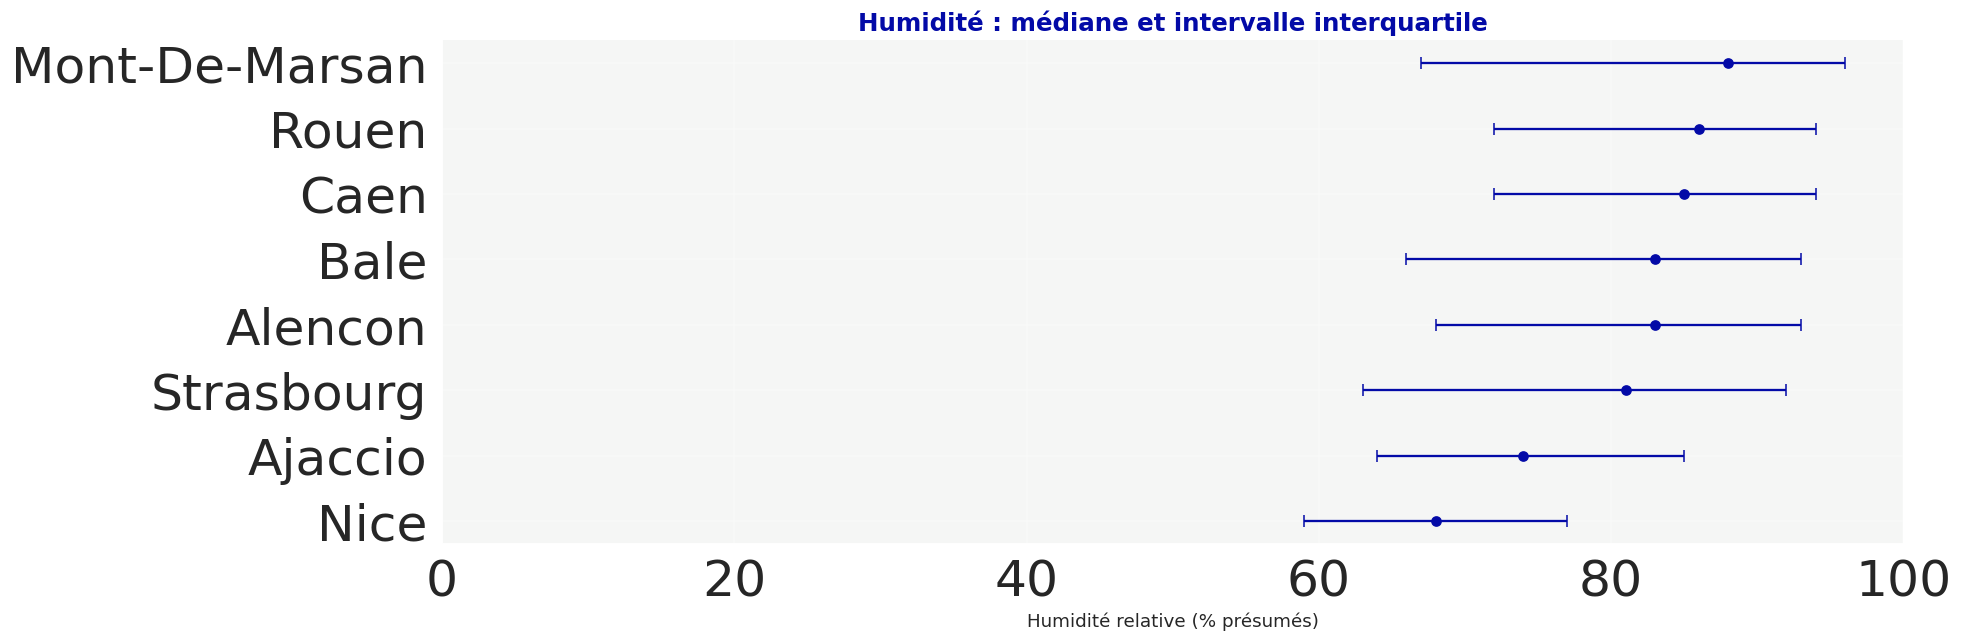

In [12]:
table = periode.groupby('Nom').Humidite.agg(moyenne='mean', mediane='median', q25=lambda s: s.quantile(.25), q75=lambda s: s.quantile(.75), n='count').reset_index()
sauver(table, 'g07_humidite_stations')
vue = table.loc[table.Nom.isin(stations)].dropna(subset=['mediane']).sort_values('mediane')
if not vue.empty:
    fig, ax = plt.subplots()
    ax.errorbar(vue.mediane, vue.Nom, xerr=np.vstack([vue.mediane-vue.q25, vue.q75-vue.mediane]), fmt='o', capsize=4)
    ax.set(title='Humidité : médiane et intervalle interquartile', xlabel='Humidité relative (% présumés)', xlim=(0, 100))
    terminer(fig, '07_humidite')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 08 — Pression atmosphérique</div></b>

**Objectif :** suivre les variations de pression.

**Variables :** date, station et pression.

**Préparation :** moyennes quotidiennes et réindexation des jours manquants.

**Lecture :** comparer d'abord les variations au sein d'une station ; le fichier ne précise pas si la pression est ramenée au niveau de la mer. Les différences d'altitude peuvent produire des décalages permanents.

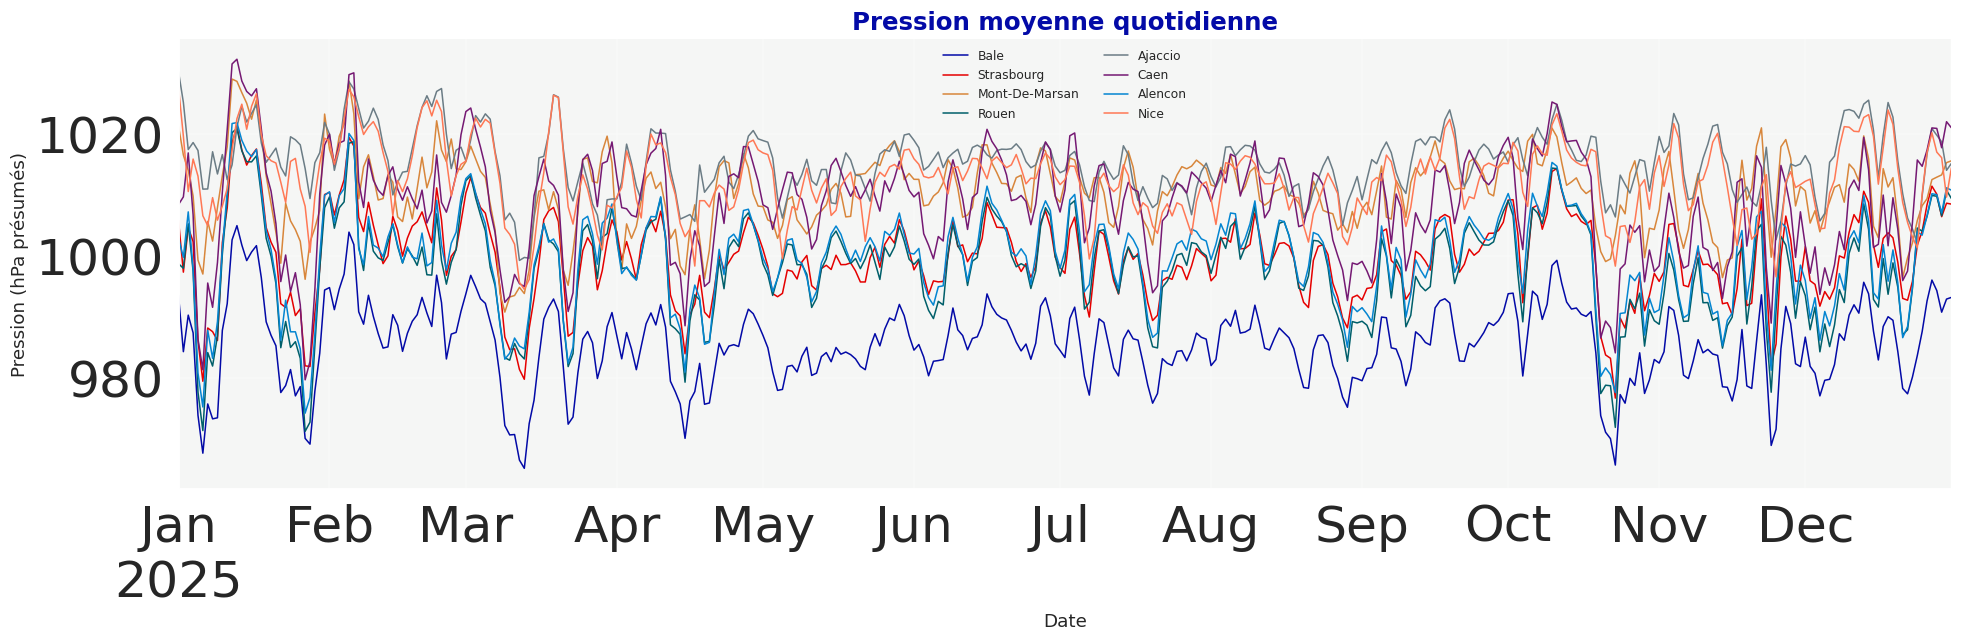

In [13]:
table = journalier.pivot(index='Jour', columns='Nom', values='pression')
table = table.reindex(pd.date_range(periode.Jour.min(), periode.Jour.max(), freq='D'))
table.index.name = 'Jour'
sauver(table.reset_index(), 'g08_pression')
if disponible(periode, ['Pression']):
    fig, ax = plt.subplots()
    table.reindex(columns=stations).plot(ax=ax, linewidth=1)
    ax.set(title='Pression moyenne quotidienne', xlabel='Date', ylabel='Pression (hPa présumés)')
    ax.legend(fontsize=8, ncol=2)
    terminer(fig, '08_pression')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 09 — Ensoleillement : données non disponibles</div></b>

**Objectif :** analyser la durée d'ensoleillement, si elle est mesurée.

**Variables requises :** durée d'insolation ou rayonnement accompagné de sa définition et de son unité.

**Inspection :** aucune colonne correspondante n'existe dans ce fichier.

**Lecture :** aucun graphique n'est fabriqué ; la visibilité ne permet pas de déduire la durée d'ensoleillement.

In [14]:
# Conserver la raison de l'absence comme table Parquet de traçabilité.
statut = pd.DataFrame([{'graphique': 'Ensoleillement', 'disponible': False,
    'raison': "Aucune mesure d'ensoleillement dans le schéma inspecté."}])
sauver(statut, 'g09_statut_ensoleillement')
display(statut)

,graphique,disponible,raison
0,Ensoleillement,False,Aucune mesure d'ensoleillement dans le schéma ...


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Comparaisons et distributions</div></b>

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 10 — Top 10 des stations les plus pluvieuses</div></b>

**Objectif :** classer les stations selon la somme de précipitations enregistrée sur la période commune sélectionnée.

**Variables :** station et précipitation.

**Préparation :** sommer les observations uniques non négatives ; fournir le nombre de mesures et de jours observés.

**Lecture :** un faible total peut provenir de données manquantes. Ce classement descriptif ne corrige ni les lacunes ni les éventuels chevauchements d'accumulation ; il ne constitue pas un classement climatique.

,Nom,total,n_valides,n_releves,jours_observes,taux_valides
8,Brest,1190.4,2629,2895,365,0.908117
22,Montelimar,920.5,2660,2843,364,0.935631
17,Limoges,878.3,2659,2913,360,0.912805
36,St Girons,843.0,2830,2916,365,0.970508
6,Bordeaux,838.2,2716,2910,365,0.933333
24,Nancy,827.7,2701,2893,364,0.933633
14,Gourdon,821.0,2631,2780,361,0.946403
21,Mont-De-Marsan,820.7,2706,2916,365,0.927984
13,Embrun,809.2,2902,2908,365,0.997937
18,Lyon,793.4,2672,2909,365,0.918529


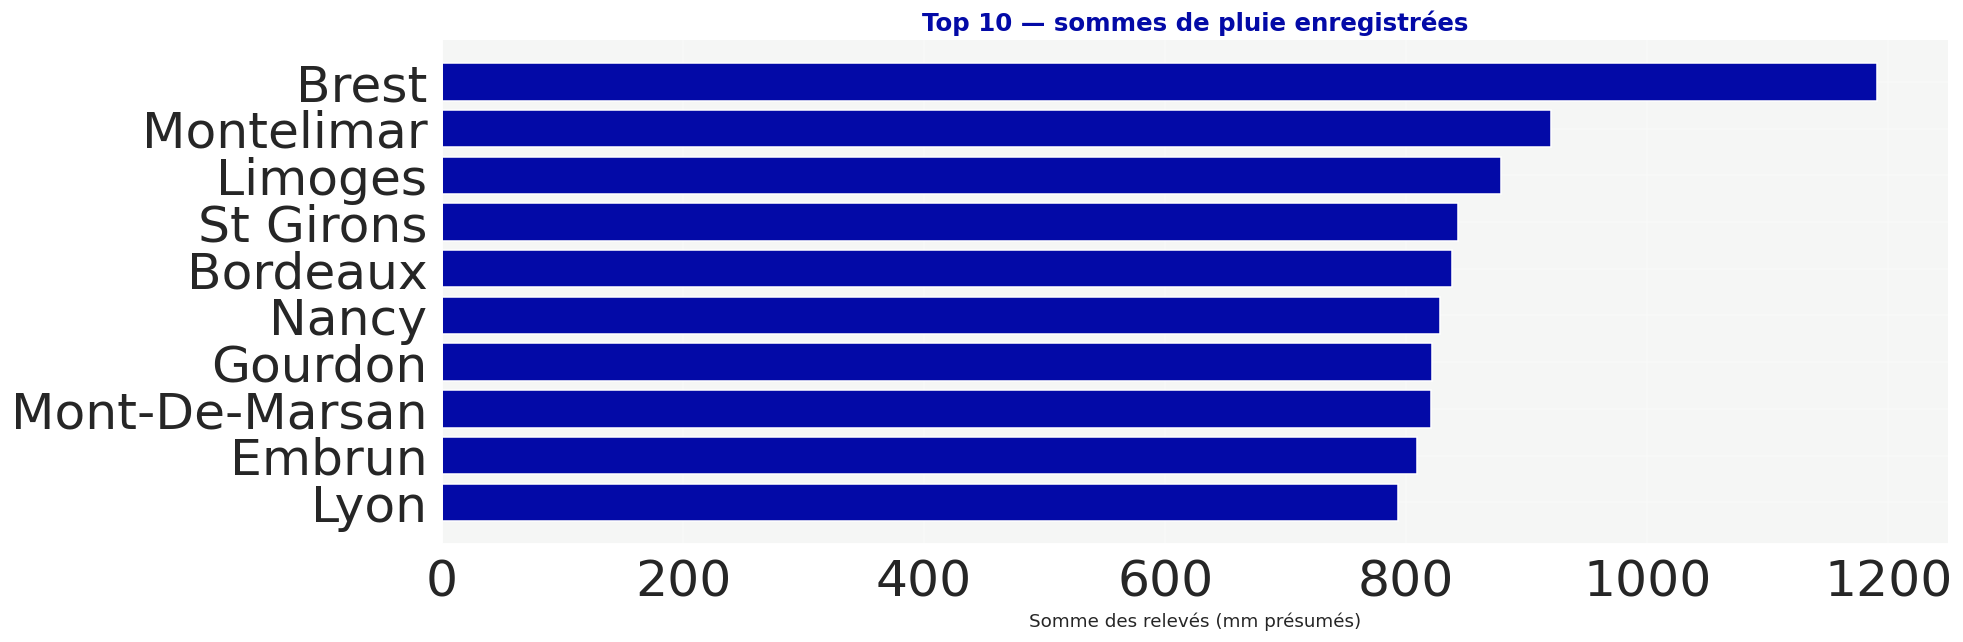

In [15]:
table = periode.groupby('Nom').agg(total=('Precipitation', lambda s: s.sum(min_count=1)),
    n_valides=('Precipitation', 'count'), n_releves=('DateHeure', 'count')).reset_index()
jours = periode.loc[periode.Precipitation.notna()].groupby('Nom').Jour.nunique()
table['jours_observes'] = table.Nom.map(jours).fillna(0).astype(int)
table['taux_valides'] = table.n_valides / table.n_releves
table = table.sort_values('total', ascending=False)
sauver(table, 'g10_classement_pluie_complet')
top = table.dropna(subset=['total']).head(10)
sauver(top, 'g10_top10_pluie')
display(top)
if not top.empty:
    fig, ax = plt.subplots()
    ax.barh(top.Nom.iloc[::-1], top.total.iloc[::-1], color=palette[0])
    ax.set(title='Top 10 — sommes de pluie enregistrées', xlabel='Somme des relevés (mm présumés)')
    terminer(fig, '10_top10_pluie')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 11 — Matrice de corrélation</div></b>

**Objectif :** explorer les associations linéaires entre mesures.

**Variables :** température, pluie, humidité, pression, vitesse du vent et visibilité.

**Préparation :** corrélation de Pearson sur les paires non manquantes, au moins 30 paires ; sauvegarder aussi les effectifs de chaque paire. Exclure les identifiants calendaires et la direction du vent, variable circulaire.

**Lecture :** −1 à +1 ; gris signifie indéfini. Une corrélation n'est pas une causalité et peut refléter les saisons ou le mélange des stations.

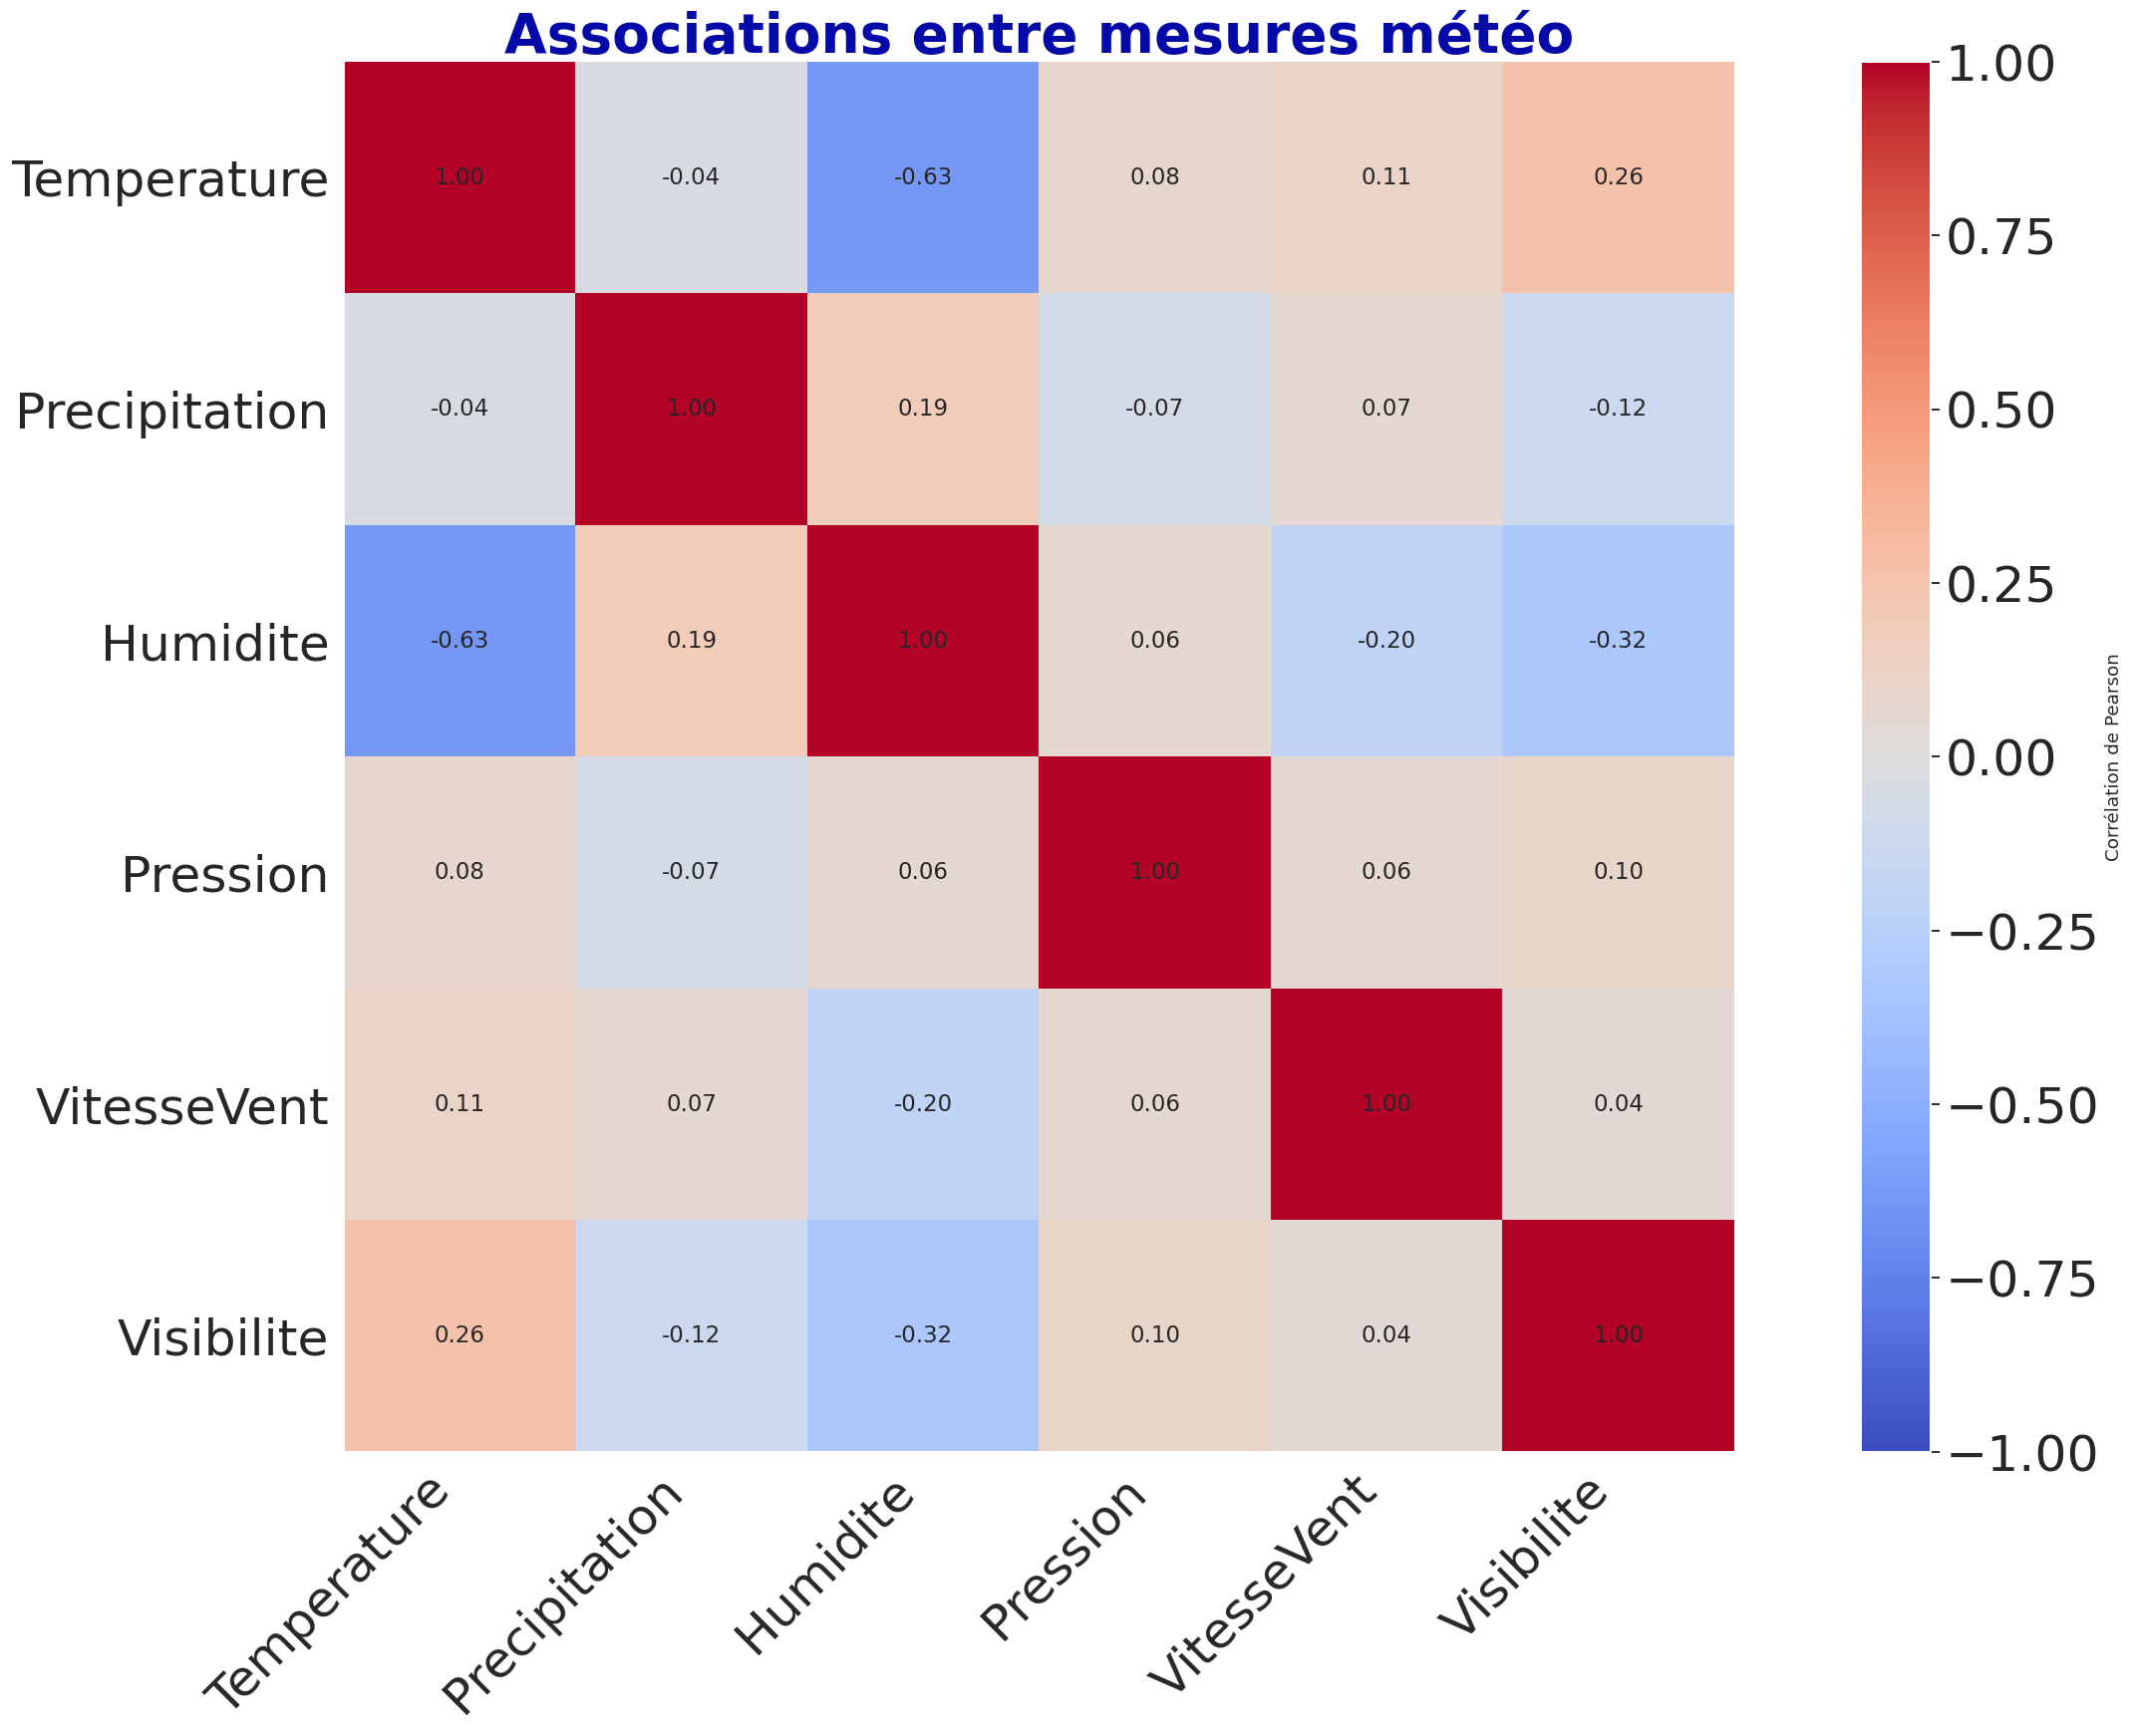

In [16]:
colonnes_corr = [c for c in ['Temperature', 'Precipitation', 'Humidite', 'Pression', 'VitesseVent', 'Visibilite'] if c in periode]
valeurs = periode[colonnes_corr]
corr = valeurs.corr(min_periods=30)
validite = valeurs.notna().astype('int64')
effectifs = validite.T.dot(validite)
sauver(corr.rename_axis('variable').reset_index(), 'g11_correlations')
sauver(effectifs.rename_axis('variable').reset_index(), 'g11_effectifs_paires')
fig, ax = plt.subplots(figsize=(24, 16))
palette_correlation = plt.get_cmap('coolwarm').copy()
palette_correlation.set_bad('lightgray')
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap=palette_correlation)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.index)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}' if pd.notna(v) else 'N/D', ha='center', va='center', fontsize=15)
fig.colorbar(im, ax=ax, label='Corrélation de Pearson')
ax.set_title('Associations entre mesures météo', size=36)
terminer(fig, '11_correlations')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 12 — Distribution des précipitations</div></b>

**Objectif :** distinguer l'absence de pluie de l'intensité des relevés positifs.

**Variable :** précipitation.

**Préparation :** compter séparément zéro, positif et manquant, puis histogramme des valeurs positives avec classes logarithmiques.

**Lecture :** les deux axes logarithmiques du second panneau rendent les fortes pluies rares visibles. Les valeurs négatives exclues au nettoyage ne sont pas assimilées à des jours secs.

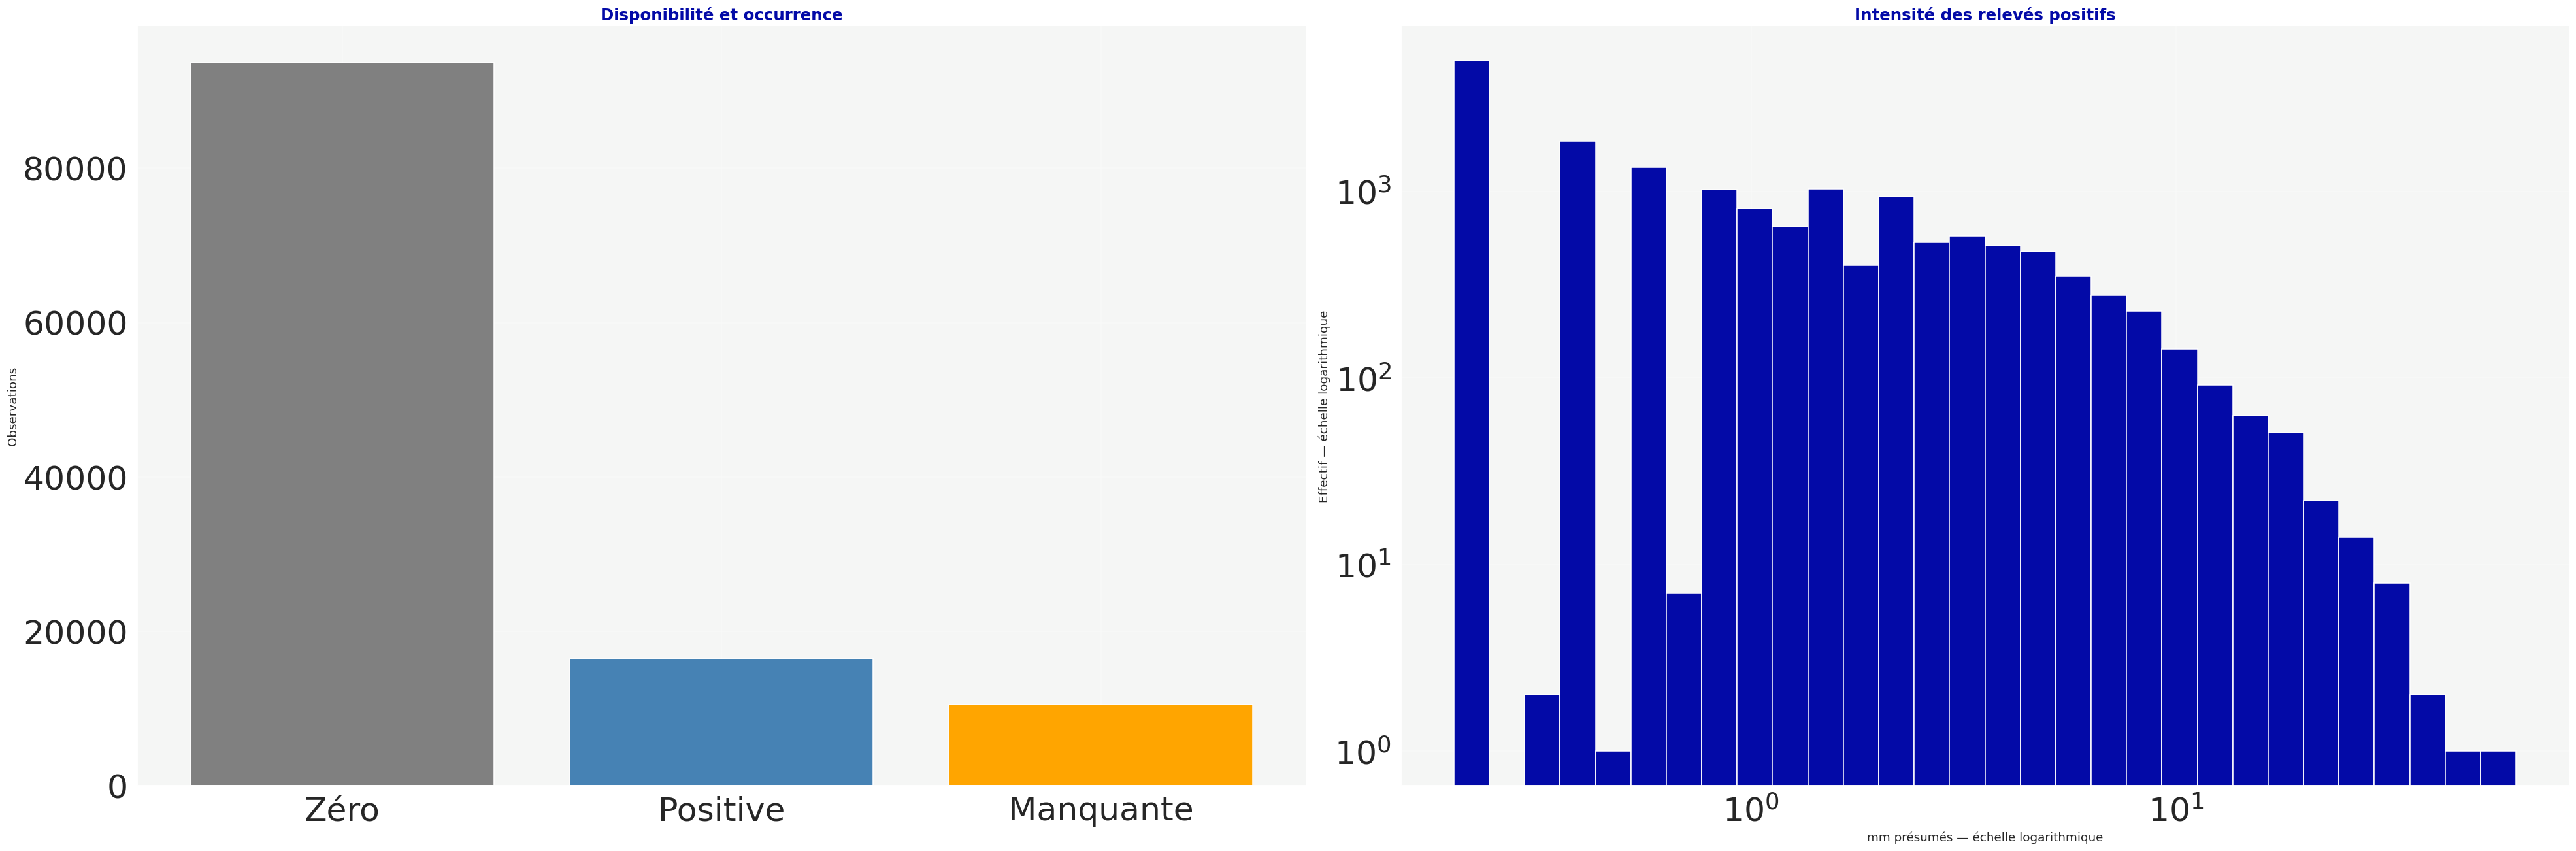

In [17]:
pluie = periode.Precipitation
comptage = pd.DataFrame({'categorie': ['Zéro', 'Positive', 'Manquante'],
                         'effectif': [pluie.eq(0).sum(), pluie.gt(0).sum(), pluie.isna().sum()]})
sauver(comptage, 'g12_etats_precipitation')
positives = pluie.loc[pluie.gt(0)]
fig, axes = plt.subplots(1, 2, figsize=(36, 12))
axes[0].bar(comptage.categorie, comptage.effectif, color=['gray', 'steelblue', 'orange'])
axes[0].set(title='Disponibilité et occurrence', ylabel='Observations')
if not positives.empty:
    bas, haut = positives.min(), positives.max()
    limites = np.geomspace(bas, haut if haut > bas else bas*1.1, 31)
    n, b = np.histogram(positives, bins=limites)
    table = pd.DataFrame({'borne_basse': b[:-1], 'borne_haute': b[1:], 'effectif': n})
    sauver(table, 'g12_distribution_pluie_positive')
    axes[1].bar(b[:-1], n, width=np.diff(b), align='edge', color=palette[0], edgecolor='white')
    axes[1].set(xscale='log', yscale='log', title='Intensité des relevés positifs', xlabel='mm présumés — échelle logarithmique', ylabel='Effectif — échelle logarithmique')
else:
    axes[1].text(.5, .5, 'Aucune précipitation positive', ha='center', transform=axes[1].transAxes)
terminer(fig, '12_distribution_precipitations')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Évolution et indicateurs météo</div></b>

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 13 — Évolution mensuelle des moyennes</div></b>

**Objectif :** comparer les évolutions de long terme.

**Variables :** température, humidité et pression ; station et mois.

**Préparation :** moyenne de chaque station/mois puis moyenne des stations, avec poids égal par station disponible et effectif explicite.

**Lecture :** quatre panneaux séparent les unités et montrent la couverture. Le dernier mois, janvier 2026, est incomplet. L'évolution du réseau empêche d'interpréter directement ces courbes comme une tendance climatique homogénéisée.

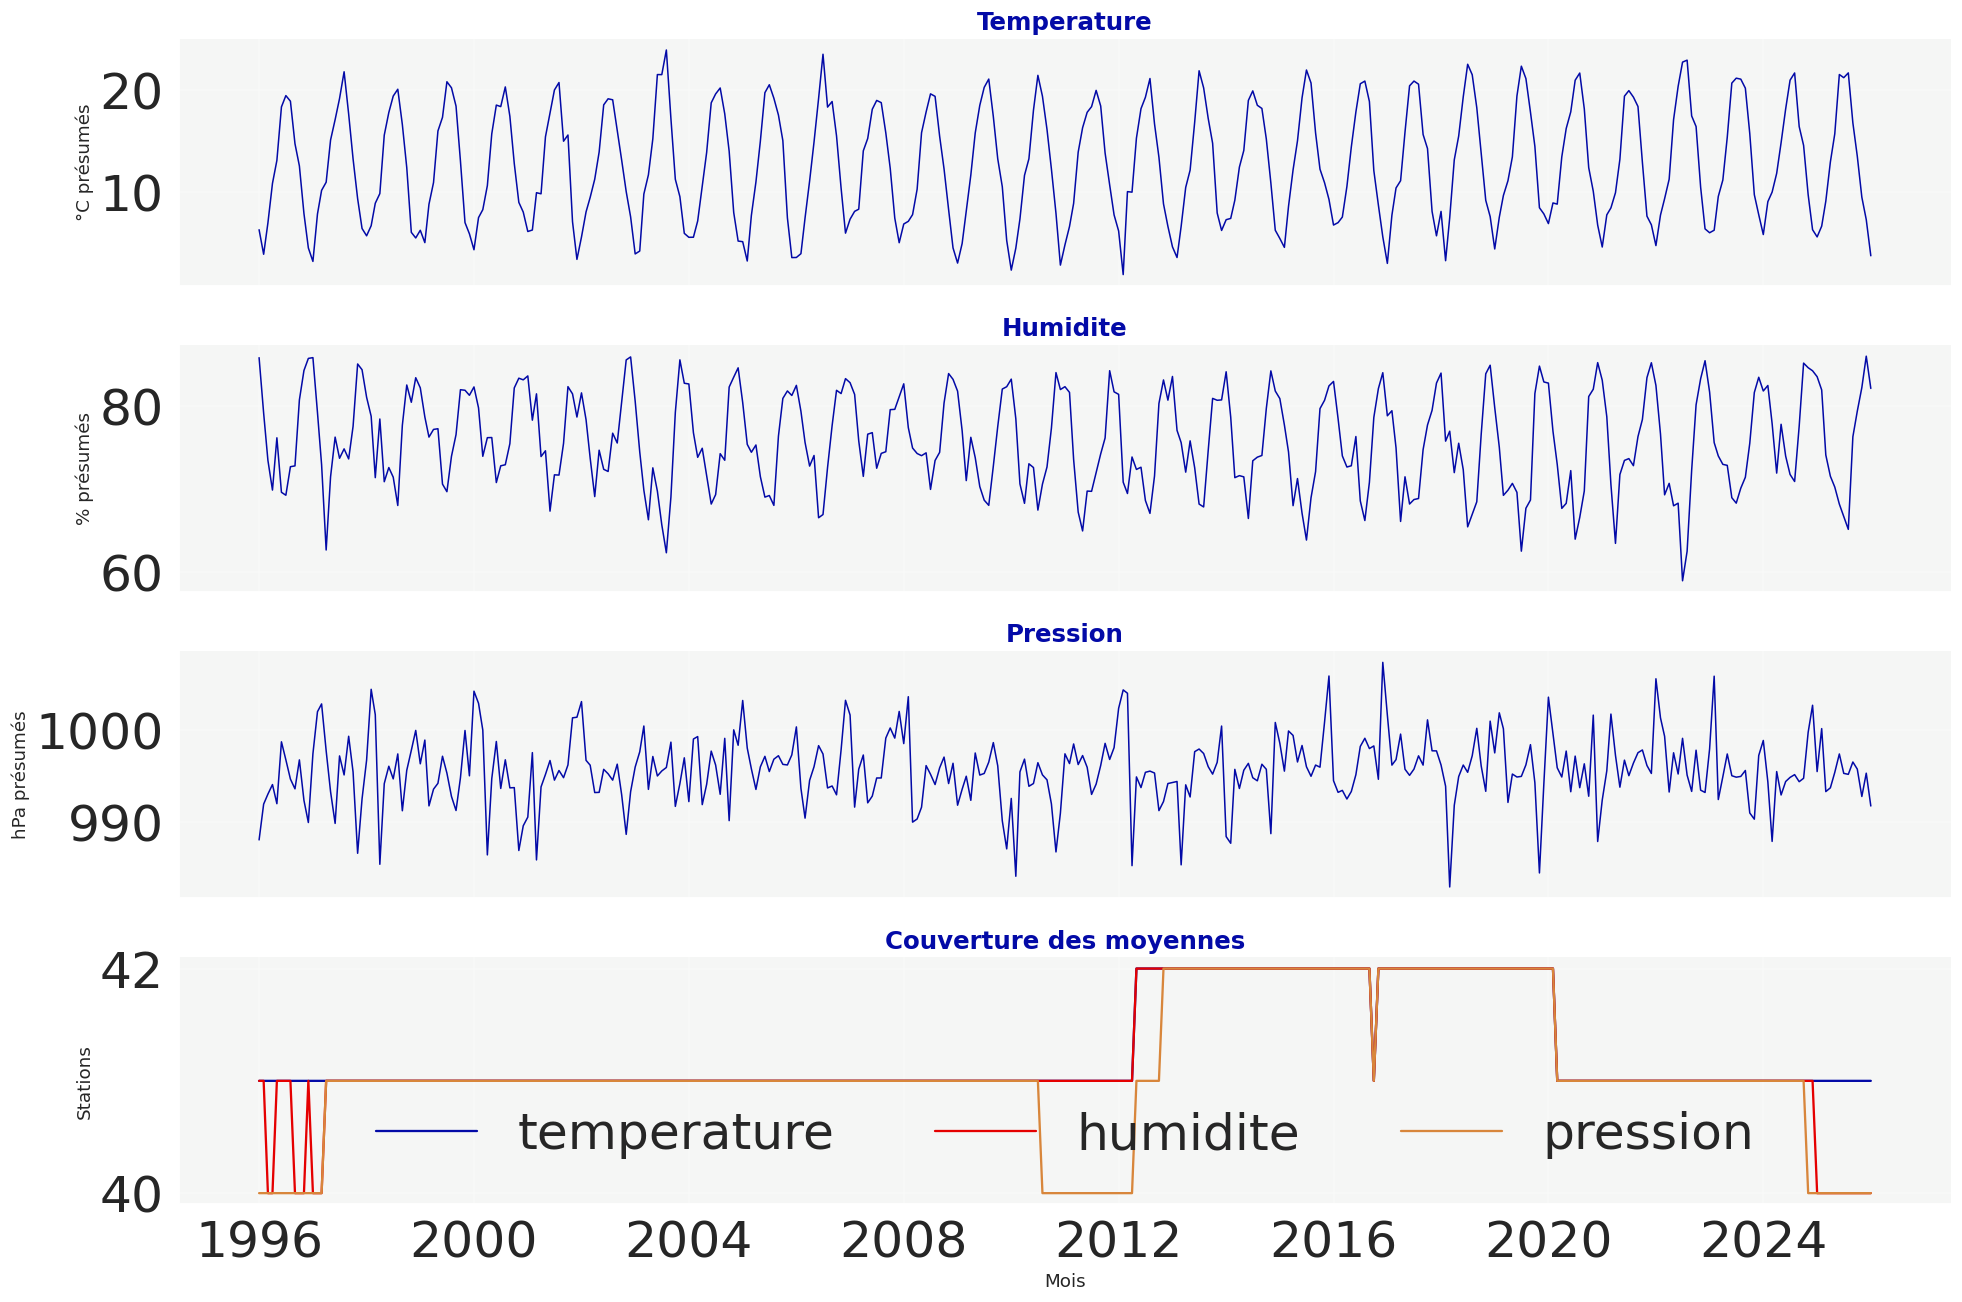

In [18]:
table = mensuel.groupby('MoisDebut').agg(temperature=('temperature', 'mean'),
    humidite=('humidite', 'mean'), pression=('pression', 'mean'),
    stations_temperature=('temperature', 'count'), stations_humidite=('humidite', 'count'),
    stations_pression=('pression', 'count')).reset_index()
sauver(table, 'g13_moyennes_mensuelles_reseau')
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(18, 12))
for ax, variable, unite in zip(axes[:3], ['temperature', 'humidite', 'pression'], ['°C', '%', 'hPa']):
    ax.plot(table.MoisDebut, table[variable], linewidth=1)
    ax.set(ylabel=unite+' présumés', title=variable.capitalize())
for variable in ['temperature', 'humidite', 'pression']:
    axes[3].plot(table.MoisDebut, table['stations_'+variable], label=variable)
axes[3].set(ylabel='Stations', xlabel='Mois', title='Couverture des moyennes')
axes[3].legend(ncol=3)
terminer(fig, '13_evolution_mensuelle')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Graphique 14 — Indicateurs météo dérivés</div></b>

**Objectif :** compter des situations directement définissables par les mesures.

**Variables :** température, pluie, humidité.

**Préparation :** indicateurs indépendants « gel : T < 0 », « précipitation mesurée > 0 », « forte humidité ≥ 90 ». Chaque proportion utilise son propre nombre de mesures valides ; conserver NA pour les inconnues.

**Lecture :** les catégories se recouvrent et ne totalisent pas 100 %. Ce ne sont pas des types météorologiques officiels : pluie/neige, orage, brouillard et ciel ensoleillé ne sont pas déduits sans codes ou métadonnées appropriés.

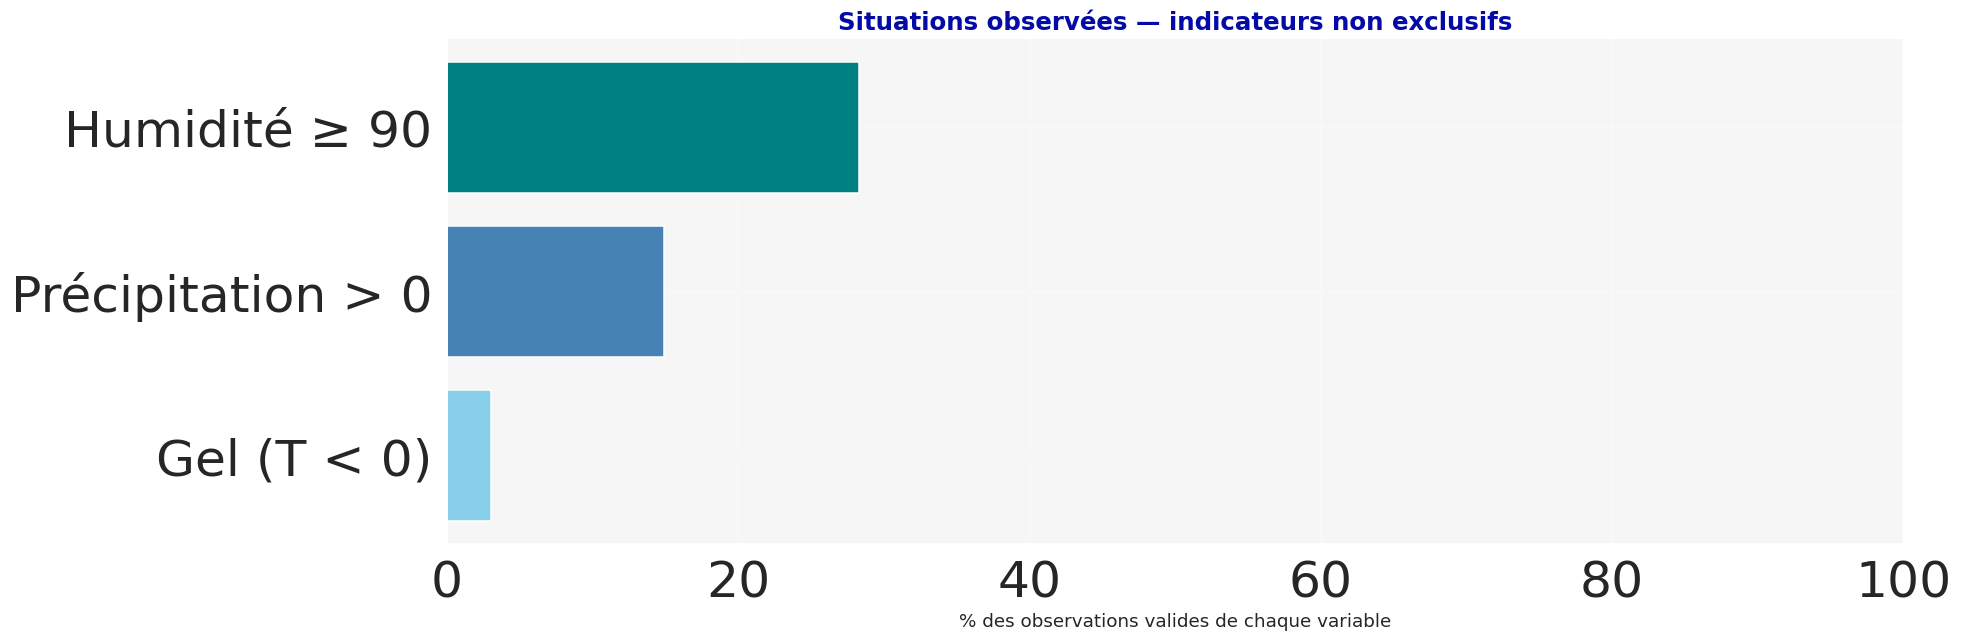

In [19]:
indicateurs = periode[['Nom', 'DateHeure']].copy()
definitions = [('Gel (T < 0)', 'Temperature', lambda s: s < 0),
               ('Précipitation > 0', 'Precipitation', lambda s: s > 0),
               ('Humidité ≥ 90', 'Humidite', lambda s: s >= 90)]
resume = []
for nom, variable, condition in definitions:
    # Le booléen nullable évite de transformer les inconnues en False.
    serie = condition(periode[variable]).astype('boolean').mask(periode[variable].isna())
    indicateurs[nom] = serie
    n = int(serie.count())
    positifs = int(serie.sum())
    resume.append({'indicateur': nom, 'effectif': positifs, 'mesures_valides': n,
                   'pourcentage': 100*positifs/n if n else np.nan})
table = pd.DataFrame(resume)
sauver(indicateurs, 'g14_indicateurs_observations')
sauver(table, 'g14_frequences_indicateurs')
fig, ax = plt.subplots()
ax.barh(table.indicateur, table.pourcentage, color=['skyblue', 'steelblue', 'teal'])
ax.set(xlabel='% des observations valides de chaque variable', xlim=(0, 100), title='Situations observées — indicateurs non exclusifs')
terminer(fig, '14_indicateurs_meteo')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align:left'>Contrôles et sauvegardes</div></b>

Le jeu final reprend toutes les lignes nettoyées avec les repères temporels calculés. Les observations uniques, la période graphique, les statistiques journalières/mensuelles et les tables propres aux graphiques sont sauvegardées séparément. Le manifeste Parquet indique le nom, la taille et les dimensions de chaque table. Les données brutes permettent de réviser toutes les décisions de nettoyage. Les PNG se trouvent dans `figures/`.

In [20]:
sauver(df, '99_meteo_final')
inventaire = []
for chemin in sorted(DATA.glob('*.parquet')):
    if chemin.name == '99_manifeste.parquet':
        continue
    metadata = pq.ParquetFile(chemin).metadata
    inventaire.append({'fichier': chemin.name, 'lignes': metadata.num_rows,
                      'colonnes': metadata.num_columns, 'octets': chemin.stat().st_size})
manifeste = sauver(pd.DataFrame(inventaire), '99_manifeste')
assert not list(DATA.glob('*.csv')) and not list(DATA.glob('*.json'))
display(manifeste)
print('Exports terminés :', len(manifeste), 'tables Parquet et', len(list(FIGURES.glob('*.png'))), 'figures PNG.')

,fichier,lignes,colonnes,octets
0,00_brutes.parquet,3603593,21,38733224
1,01_inspection.parquet,21,4,3302
2,02_bilan_nettoyage.parquet,10,2,1968
3,03_nettoyees.parquet,3603412,24,42889235
4,04_observations_uniques.parquet,3603407,14,38113477
5,05_periode_graphiques.parquet,120656,14,1032734
6,06_statistiques_journalieres.parquet,15285,10,203779
7,07_statistiques_mensuelles.parquet,14965,8,468833
8,99_meteo_final.parquet,3603412,24,42889235
9,g01_temperature_par_station.parquet,365,43,120439


Exports terminés : 28 tables Parquet et 13 figures PNG.
